# Water Quality Analysis & Predictive Maintenance

## Necessary Libraries Import

In [2]:
# import python libraries

import numpy as np 
import pandas as pd 
from dateutil import parser
import matplotlib.pyplot as plt # visualizing data
%matplotlib inline
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import streamlit as st

## Import Dataset

In [3]:
# import csv file
df = pd.read_csv('England_dataset.csv')

#### Shape of the Dataset

In [4]:
print("Shape of dataset:", df.shape)

Shape of dataset: (2129198, 14)


## Dataset Explore & Acquisition

#### 1. Print Column Names

In [252]:
print("\nColumn names:\n", df.columns)


Column names:
 Index(['Country', 'Area', 'Waterbody Type', 'Date', 'Ammonia (mg/l)',
       'Biochemical Oxygen Demand (mg/l)', 'Dissolved Oxygen (mg/l)',
       'Orthophosphate (mg/l)', 'pH (ph units)', 'Temperature (cel)',
       'Nitrogen (mg/l)', 'Nitrate (mg/l)', 'CCME_Values', 'CCME_WQI',
       'Formatted_Date'],
      dtype='object')


#### 2. Print Data Types

In [6]:
print("\nData types:\n", df.dtypes)


Data types:
 Country                              object
Area                                 object
Waterbody Type                       object
Date                                 object
Ammonia (mg/l)                      float64
Biochemical Oxygen Demand (mg/l)    float64
Dissolved Oxygen (mg/l)             float64
Orthophosphate (mg/l)               float64
pH (ph units)                       float64
Temperature (cel)                   float64
Nitrogen (mg/l)                     float64
Nitrate (mg/l)                      float64
CCME_Values                         float64
CCME_WQI                             object
dtype: object


#### 3. Print First Five Rows of the Dataset

In [7]:
print("\nFirst 5 rows:\n", df.head())


First 5 rows:
    Country                                      Area Waterbody Type  \
0  England  MISC.10KM SQ HISTON.................TL46          River   
1  England  MISC.10KM SQ HISTON.................TL46          River   
2  England  MISC.10KM SQ HISTON.................TL46          River   
3  England  MISC.10KM SQ HISTON.................TL46          River   
4  England  MISC.10KM SQ HISTON.................TL46          River   

         Date  Ammonia (mg/l)  Biochemical Oxygen Demand (mg/l)  \
0  01-01-2019           23.40                            152.00   
1  01-01-2019           21.30                            102.00   
2  01-01-2019            4.03                             12.50   
3  01-01-2019            5.09                              4.18   
4  01-01-2019            5.10                              3.58   

   Dissolved Oxygen (mg/l)  Orthophosphate (mg/l)  pH (ph units)  \
0                     10.2                  3.900           7.78   
1                 

#### 4. Print Last Five Rows of the Dataset

In [8]:
print("\nLast 5 rows:\n", df.tail())


Last 5 rows:
          Country                              Area Waterbody Type        Date  \
2129193  England     RAY AT MORRIS STREET, SWINDON          River  30-12-2014   
2129194  England  BEVERLEY BROOK AT PRIESTS BRIDGE          River  30-12-2014   
2129195  England     CRIPSEY BROOK AT ONGAR BRIDGE          River  30-12-2014   
2129196  England                  ASH ABOVE THAMES          River  30-12-2014   
2129197  England    BROOKHOUSE BROOK AT BROOKHOUSE          River  30-12-2014   

         Ammonia (mg/l)  Biochemical Oxygen Demand (mg/l)  \
2129193           0.073                              2.70   
2129194           0.268                              2.70   
2129195           0.045                              2.70   
2129196           0.437                              2.70   
2129197           0.111                              2.83   

         Dissolved Oxygen (mg/l)  Orthophosphate (mg/l)  pH (ph units)  \
2129193                    11.00                  0.159  

#### 5. Format Date Column (Standard ISO Format) in a new Column

In [9]:
# Create a function to parse mixed date formats safely
def parse_mixed_date(date_str):
    try:
        return parser.parse(str(date_str), dayfirst=True)
    except Exception:
        return pd.NaT  # Not a Time (missing or invalid date)

# Apply the parser to the Date column and store in new column
df['Formatted_Date'] = df['Date'].apply(parse_mixed_date)

# Check how many dates failed to parse (optional check)
failed_dates = df['Formatted_Date'].isna().sum()
print(f"Failed to parse {failed_dates} rows.")

# Convert to standard format (YYYY-MM-DD) for display
df['Formatted_Date'] = df['Formatted_Date'].dt.strftime('%Y-%m-%d')

# Preview results
print(df[['Date', 'Formatted_Date']].head())

Failed to parse 0 rows.
         Date Formatted_Date
0  01-01-2019     2019-01-01
1  01-01-2019     2019-01-01
2  01-01-2019     2019-01-01
3  01-01-2019     2019-01-01
4  01-01-2019     2019-01-01


#### 6. Check Whether the Dates are Formatted Correctly in a new Column

In [10]:
# Print rows 312 to 317 with original and formatted date
print(df.loc[
      312:317, [
          'Date', 'Formatted_Date'
      ]
])

           Date Formatted_Date
312  12-01-2019     2019-01-12
313  14-01-2019     2019-01-14
314  14-01-2019     2019-01-14
315  14-01-2019     2019-01-14
316  14-01-2019     2019-01-14
317  14-01-2019     2019-01-14


#### 7. Filtered the Formatted Date and took Data from 2019 to 2023 in a new Data Frame for Future Analysis

In [11]:
df['Formatted_Date'] = pd.to_datetime(df['Formatted_Date'])
filtered_df = df[
    (df['Formatted_Date'] >= '2019-01-01') & 
    (df['Formatted_Date'] <= '2023-12-31')
]

#### 8. Check the new Filtered Data Frame Shape

In [12]:
print("Filtered data shape:", filtered_df.shape)

Filtered data shape: (240908, 15)


## Data Cleaning

#### 1. Print Missing Values Count

In [13]:
print("\nMissing values:\n", filtered_df.isnull().sum())


Missing values:
 Country                             0
Area                                0
Waterbody Type                      0
Date                                0
Ammonia (mg/l)                      0
Biochemical Oxygen Demand (mg/l)    0
Dissolved Oxygen (mg/l)             0
Orthophosphate (mg/l)               0
pH (ph units)                       0
Temperature (cel)                   0
Nitrogen (mg/l)                     0
Nitrate (mg/l)                      0
CCME_Values                         0
CCME_WQI                            0
Formatted_Date                      0
dtype: int64


#### 2. Print Summary Statistics of the Dataset (e.g., count, frequency, mean, std, min, max)

In [14]:
print("\nSummary statistics:\n", filtered_df.describe(include='all'))


Summary statistics:
         Country                                      Area Waterbody Type  \
count    240908                                    240908         240908   
unique        1                                     17337              9   
top     England  LYNEMOUTH COLLIERY - MINEWATER ABSTRACTI          River   
freq     240908                                       552         177188   
mean        NaN                                       NaN            NaN   
min         NaN                                       NaN            NaN   
25%         NaN                                       NaN            NaN   
50%         NaN                                       NaN            NaN   
75%         NaN                                       NaN            NaN   
max         NaN                                       NaN            NaN   
std         NaN                                       NaN            NaN   

              Date  Ammonia (mg/l)  Biochemical Oxygen Demand (mg

#### 3. Check the Number of Duplicate values in the Filtered Dataset

In [15]:
duplicate_count = filtered_df.duplicated().sum()
print("Number of duplicated rows:", duplicate_count)

Number of duplicated rows: 135


#### 4. Remove the Duplicate Values from the Filtered Dataset

In [16]:
filtered_df = filtered_df.drop_duplicates()

#### 5. Check Whether Remove Duplicate Values is Successfully Done

In [17]:
print("Duplicate rows:", filtered_df.duplicated().sum())

Duplicate rows: 0


#### 6. Delete the Unnecessary Column (e.g., Country, Date), Which is not Needed for Further Analysis

In [18]:
filtered_df = filtered_df.drop(columns=['Country', 'Date'])

#### 7. Check Whether the Columns are Deleted Successfully

In [19]:
print(filtered_df.columns)

Index(['Area', 'Waterbody Type', 'Ammonia (mg/l)',
       'Biochemical Oxygen Demand (mg/l)', 'Dissolved Oxygen (mg/l)',
       'Orthophosphate (mg/l)', 'pH (ph units)', 'Temperature (cel)',
       'Nitrogen (mg/l)', 'Nitrate (mg/l)', 'CCME_Values', 'CCME_WQI',
       'Formatted_Date'],
      dtype='object')


#### 8. Prevents mismatches like "Poor" vs "poor" vs "POOR" during grouping or modeling.

In [20]:
filtered_df.loc[:, 'CCME_WQI'] = filtered_df['CCME_WQI'].str.strip().str.title()
filtered_df.loc[:, 'Waterbody Type'] = filtered_df['Waterbody Type'].str.strip().str.title()

#### 9. Convert Waterbody Type to Category Type

In [21]:
# First, make sure it's a safe copy
filtered_df = filtered_df.copy()

# Convert 'Waterbody Type' to category type
filtered_df['Waterbody Type'] = filtered_df['Waterbody Type'].astype('category')

#### 10. Check Whether the Waterbody Type is Converted to Category Type Successfully

In [22]:
# Check the result
print(filtered_df['Waterbody Type'].dtypes)
print("Categories:", filtered_df['Waterbody Type'].cat.categories)

category
Categories: Index(['Canal', 'Drainage', 'Effluent', 'Estuarine', 'Lake', 'Marine', 'River',
       'Sea Water', 'Sewage'],
      dtype='object')


## Data Exploration (EDA)

#### 1. Univariate Analysis

In [23]:
# Set style
sns.set(style="whitegrid")

# Numerical columns
num_cols = [
    'Ammonia (mg/l)',
    'Biochemical Oxygen Demand (mg/l)',
    'Dissolved Oxygen (mg/l)',
    'Orthophosphate (mg/l)',
    'pH (ph units)',
    'Temperature (cel)',
    'Nitrogen (mg/l)',
    'Nitrate (mg/l)',
    'CCME_Values'
]

# Categorical columns
cat_cols = ['Waterbody Type', 'CCME_WQI']

##### 1.1 Kernel Density Estimation (KDE) Plots for Numerical Columns

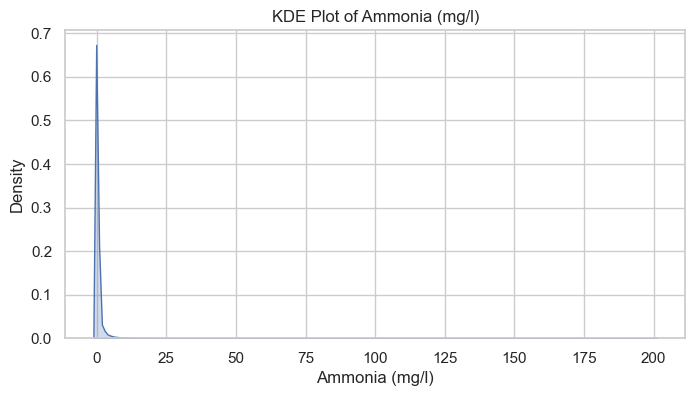

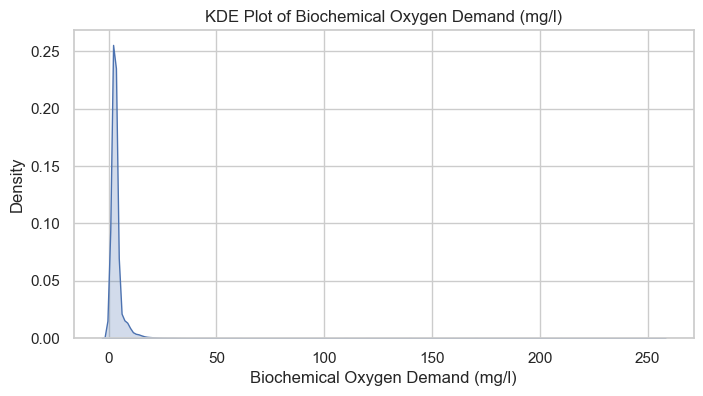

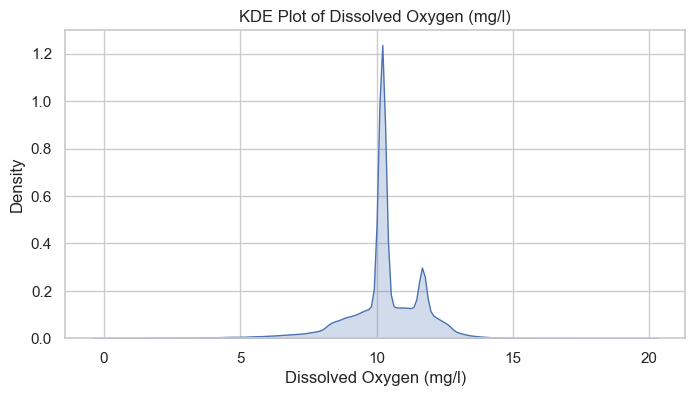

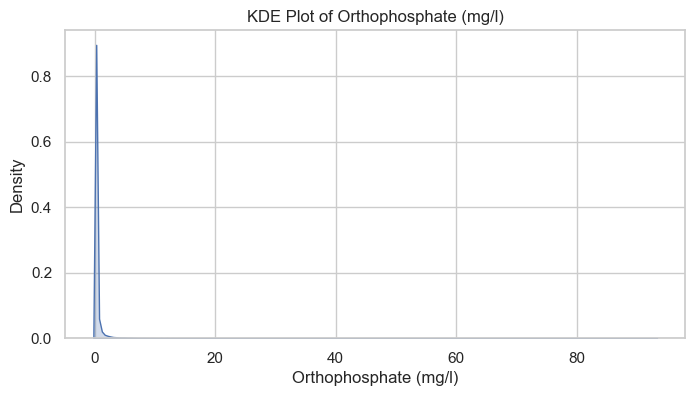

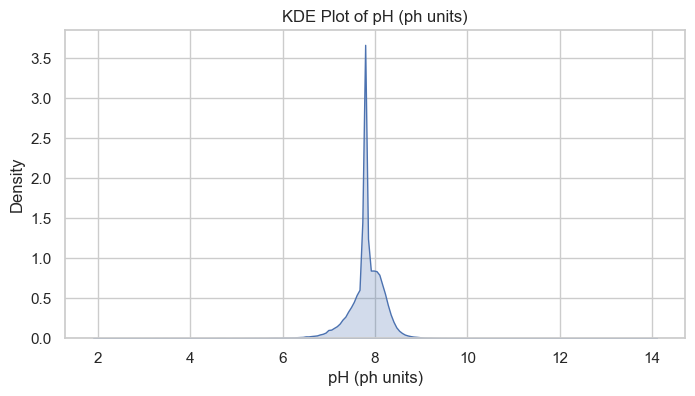

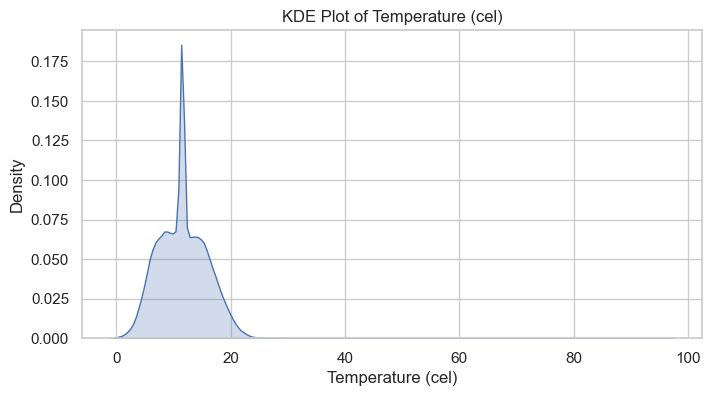

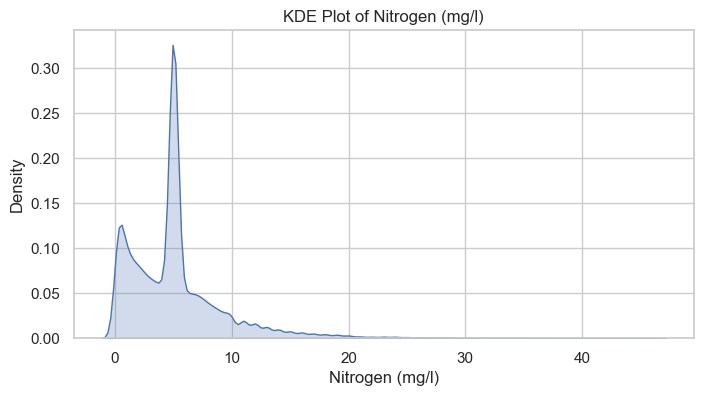

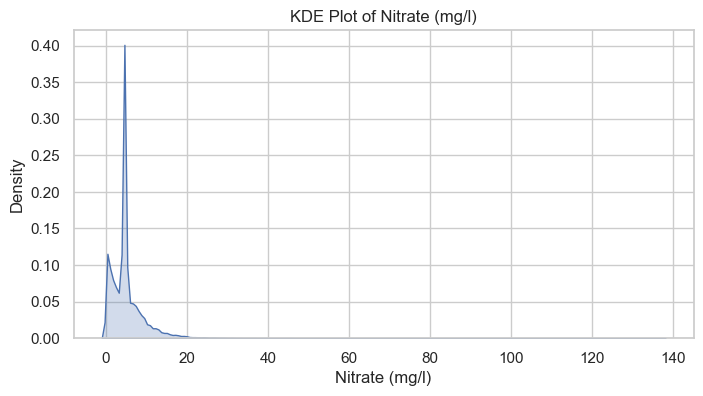

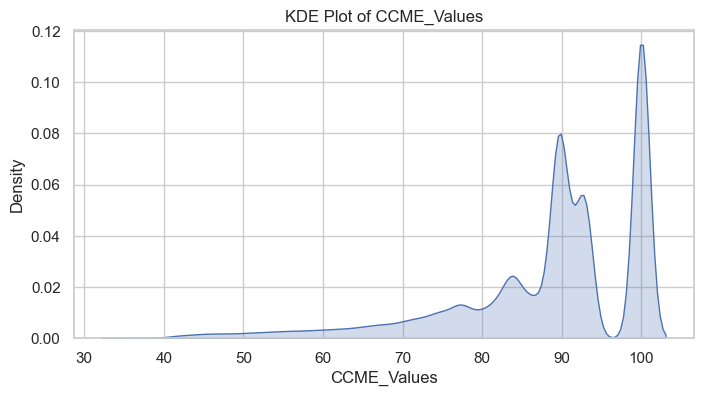

In [24]:
for col in num_cols:
    plt.figure(figsize=(8,4))
    sns.kdeplot(filtered_df[col], fill=True)
    plt.title(f"KDE Plot of {col}")
    plt.show()

##### 1.2 Pie Charts for Categorical Columns

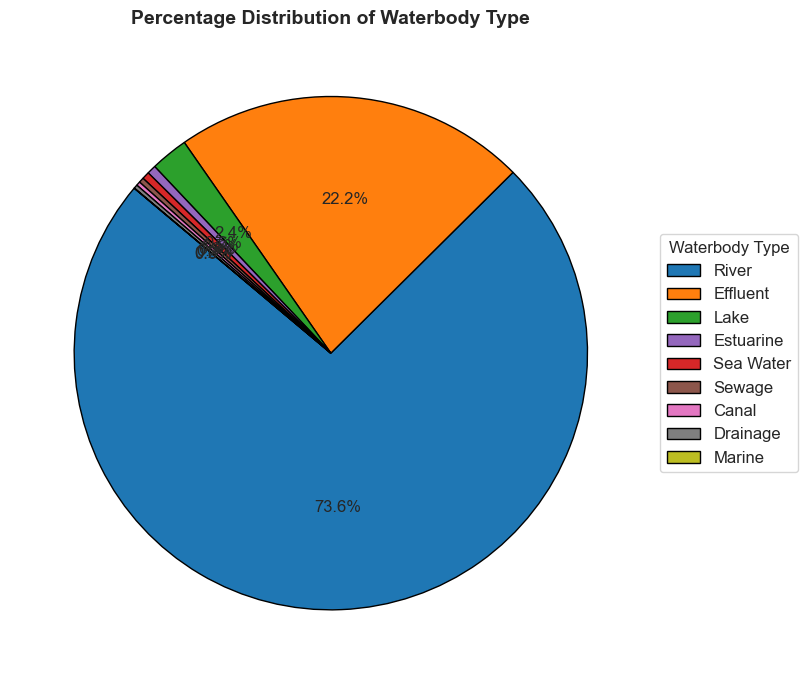

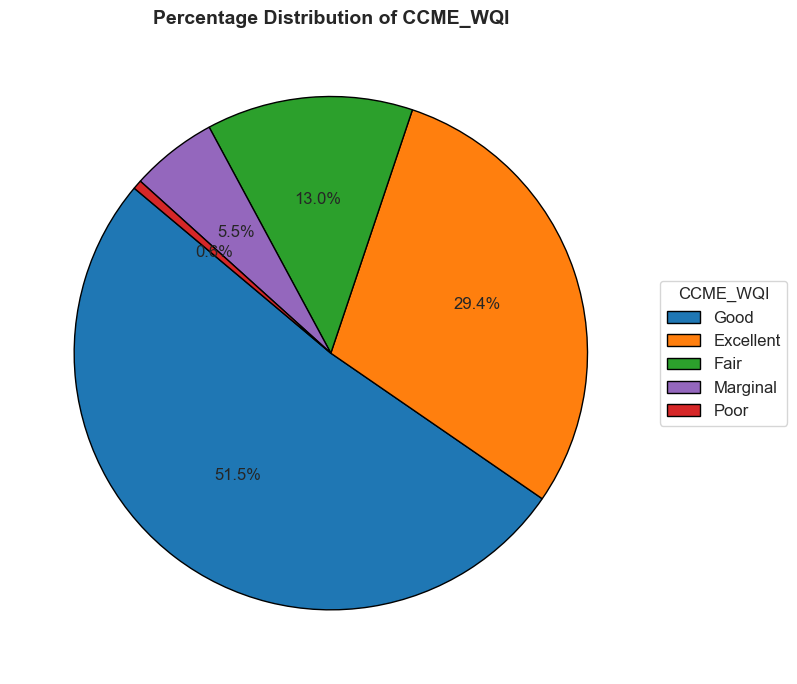

In [25]:
# Define your own custom color list (hex codes or named colors)
custom_colors = [
    "#1f77b4",  # Blue
    "#ff7f0e",  # Orange
    "#2ca02c",  # Green
    "#9467bd",  # Purple
    "#d62728",  # Red
    "#8c564b",  # Brown
    "#e377c2",  # Pink
    "#7f7f7f",  # Gray
    "#bcbd22",  # Yellow-green
    "#17becf"   # Teal
]

for col in cat_cols:
    plt.figure(figsize=(8,7))
    counts = filtered_df[col].value_counts()
    
    wedges, texts, autotexts = plt.pie(
        counts,
        autopct='%1.1f%%',
        startangle=140,
        colors=custom_colors,  # Use your custom palette
        wedgeprops={'edgecolor': 'black'},
        textprops={'fontsize': 12}
    )
    
    plt.title(f"Percentage Distribution of {col}", fontsize=14, fontweight='bold')
    
    plt.legend(
        counts.index,
        title=col,
        loc="center left",
        bbox_to_anchor=(1, 0, 0.5, 1),
        fontsize=12,
        title_fontsize=12
    )
    
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

#### 2. Bivariate/Multivariate Analysis

##### 2.1 Correlation heatmap for numeric variables

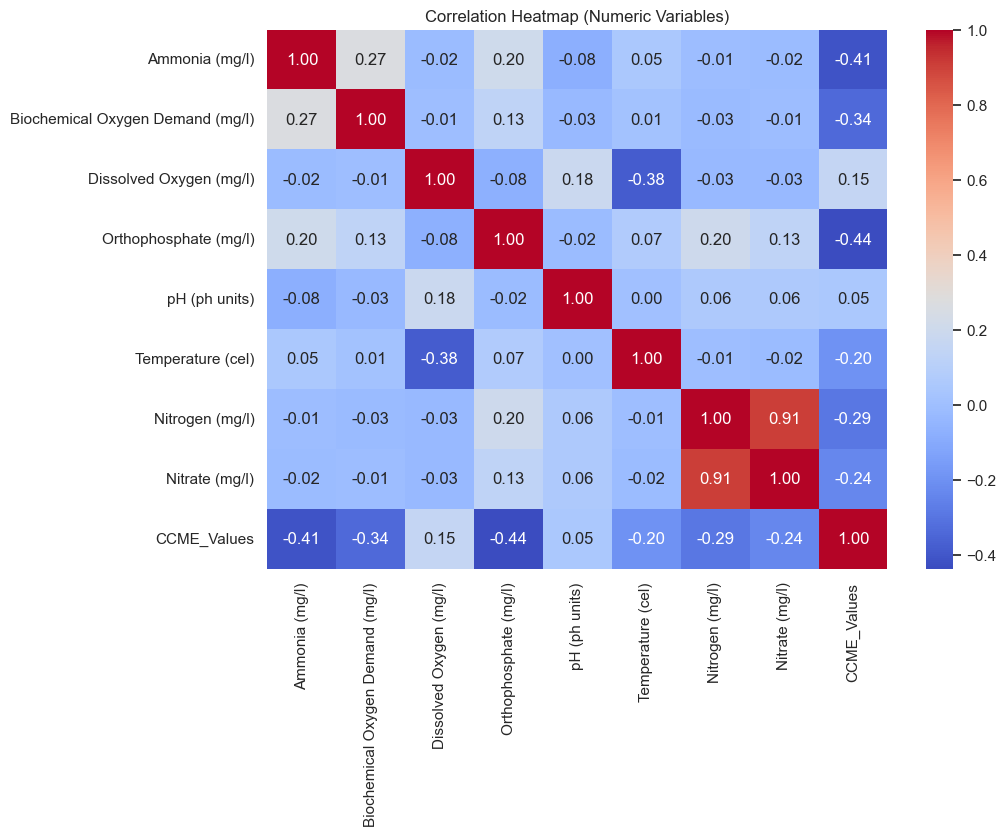

In [26]:
plt.figure(figsize=(10,7))
corr = filtered_df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap (Numeric Variables)")
plt.show()

##### 2.2 CCME_WQI vs Waterbody Type

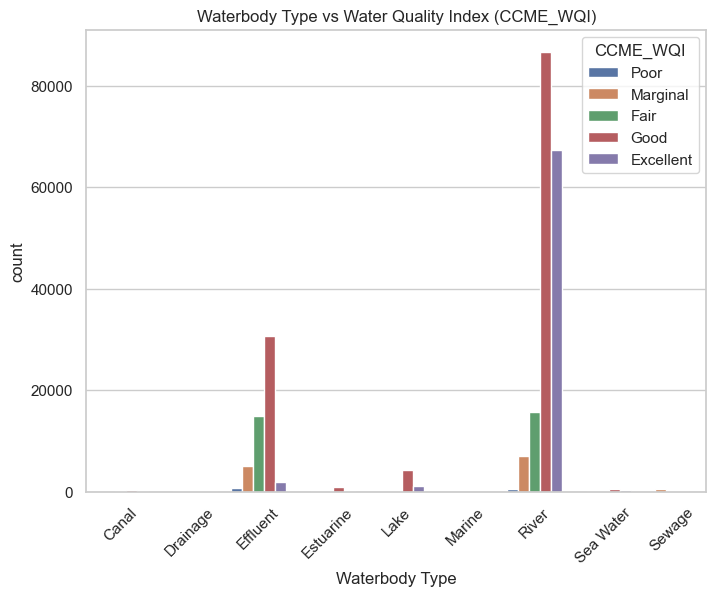

In [27]:
plt.figure(figsize=(8,6))
sns.countplot(data=filtered_df, x='Waterbody Type', hue='CCME_WQI')
plt.title("Waterbody Type vs Water Quality Index (CCME_WQI)")
plt.xticks(rotation=45)
plt.show()

##### 2.3 Dissolved Oxygen vs Temperature

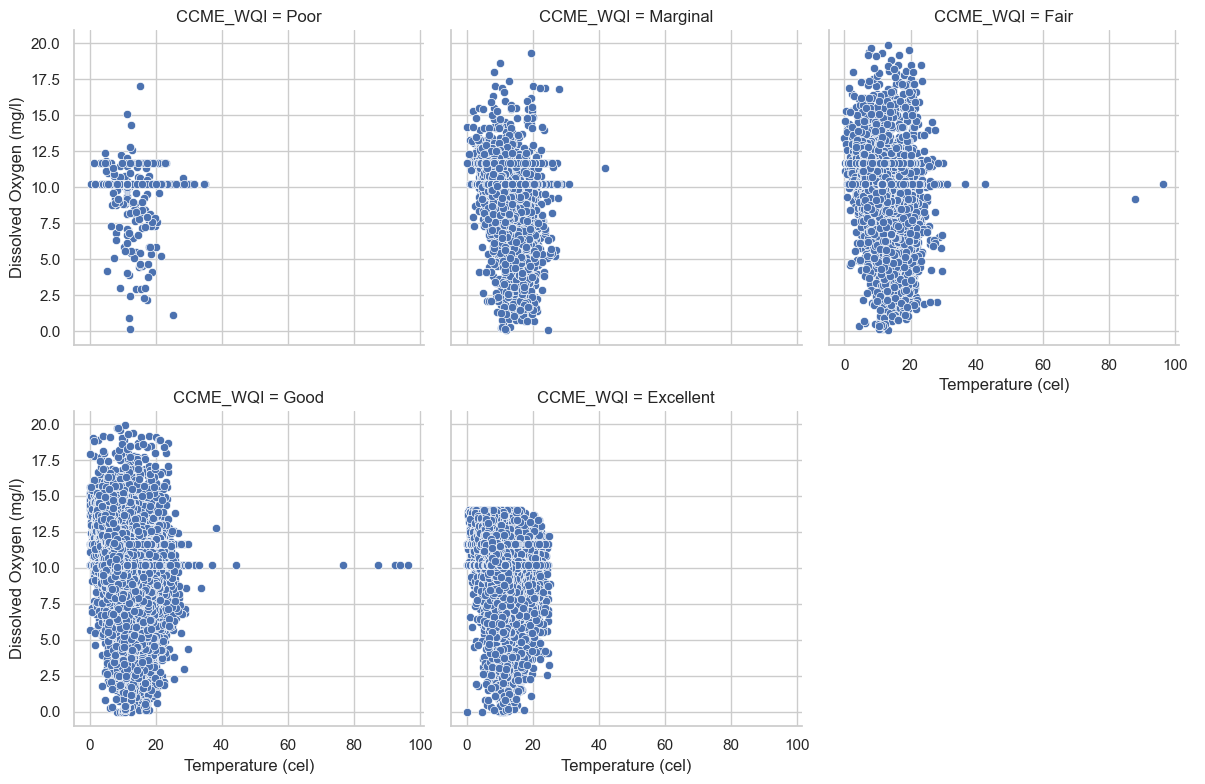

In [28]:
g = sns.FacetGrid(filtered_df, col="CCME_WQI", col_wrap=3, height=4)
g.map_dataframe(sns.scatterplot, x='Temperature (cel)', y='Dissolved Oxygen (mg/l)')
g.add_legend()
plt.show()

##### 2.4 Waterbody Type & CCME_WQI by Numerical Columns

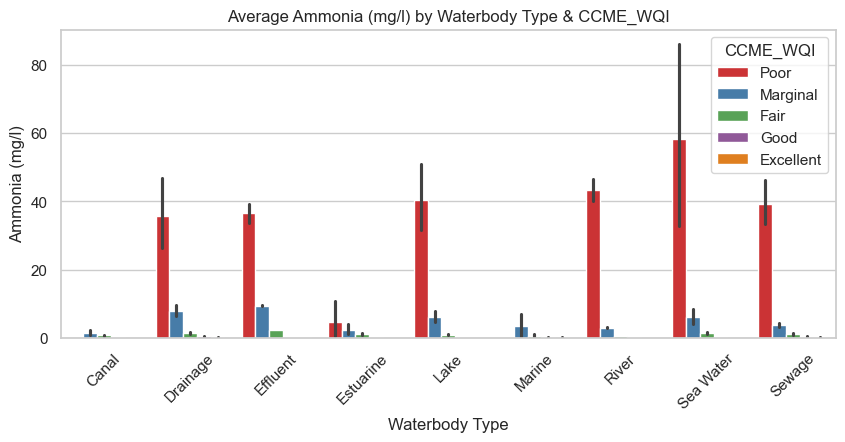

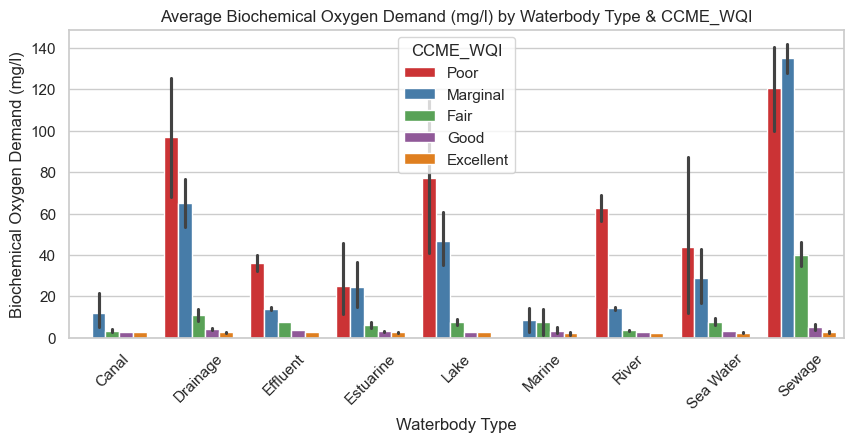

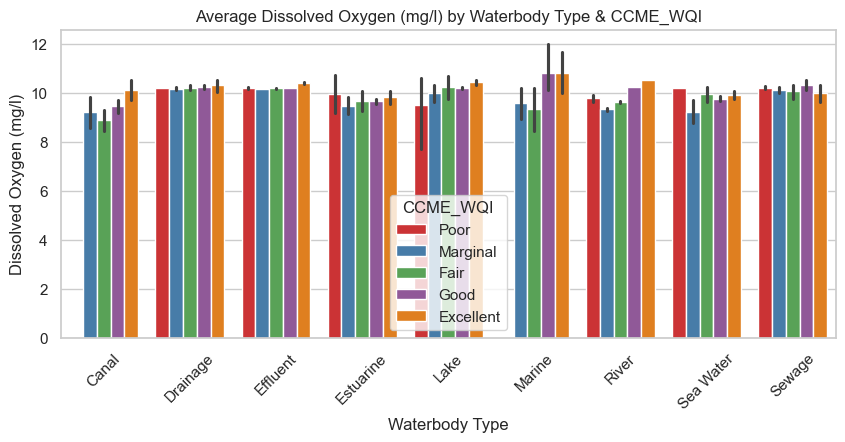

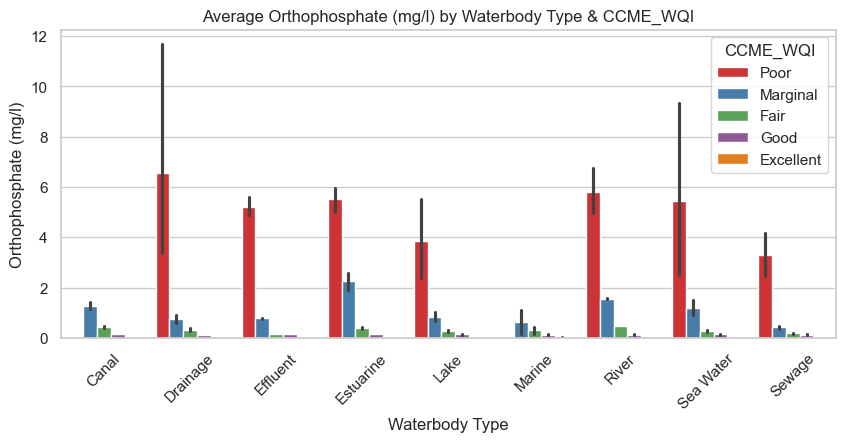

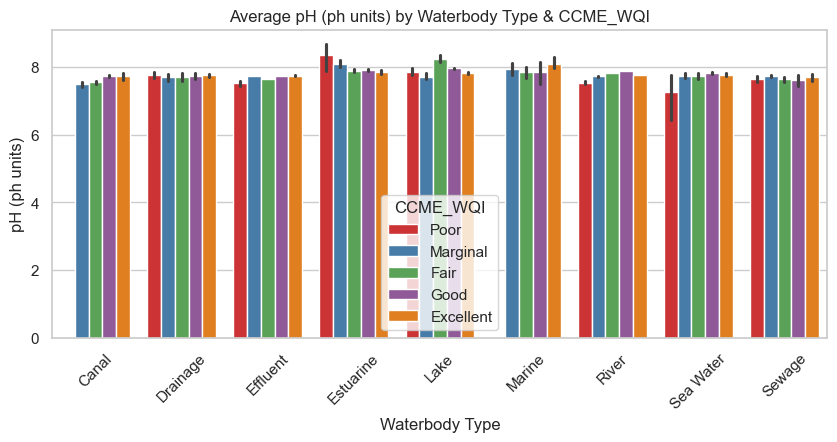

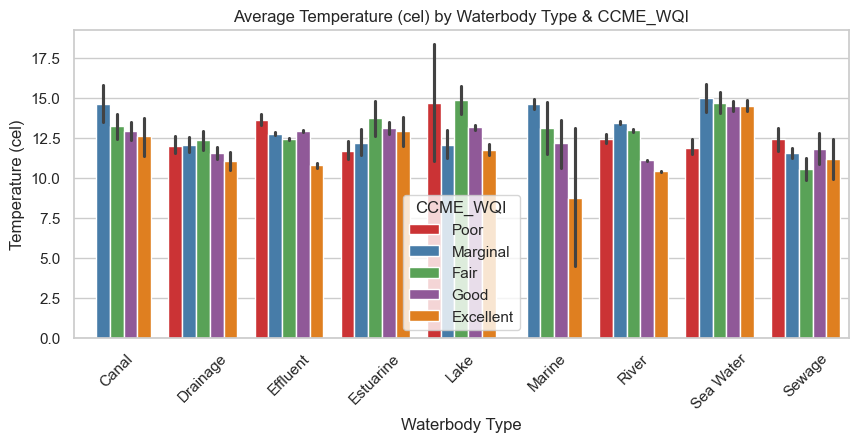

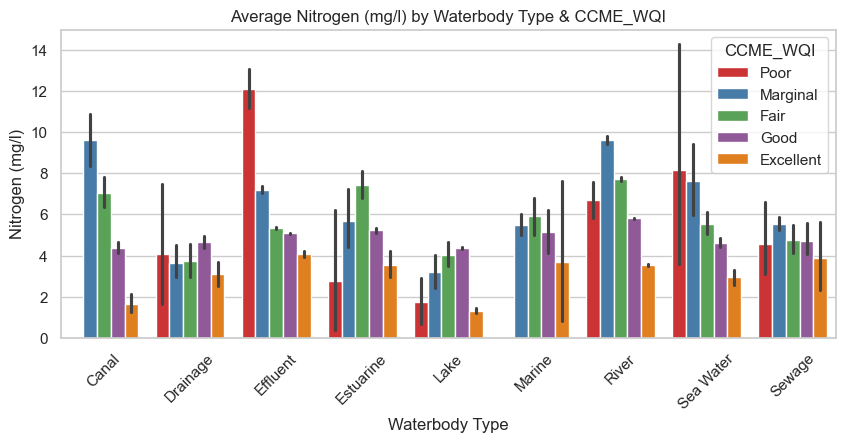

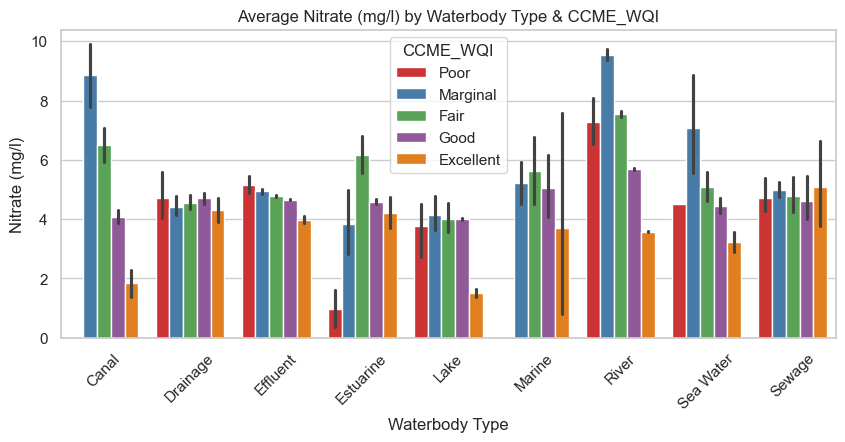

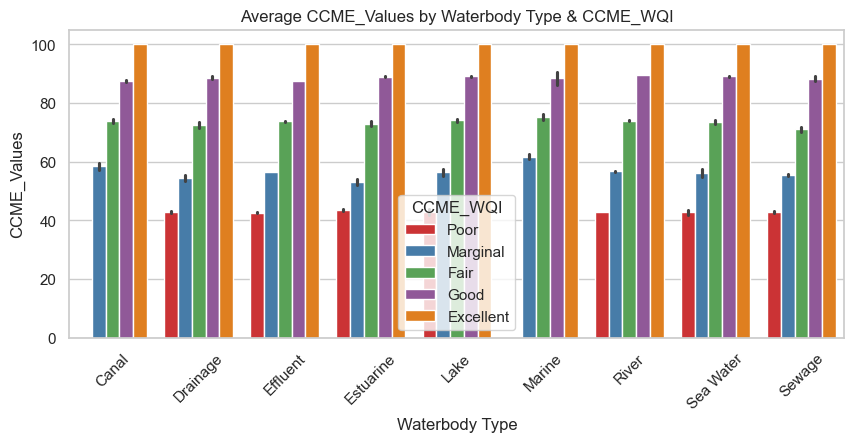

In [29]:
for col in num_cols:
    plt.figure(figsize=(10,4))
    sns.barplot(data=filtered_df, x='Waterbody Type', y=col, hue='CCME_WQI', estimator='mean', palette='Set1')
    plt.title(f"Average {col} by Waterbody Type & CCME_WQI")
    plt.xticks(rotation=45)
    plt.show()

#### 3. Time Series Analysis

In [30]:
# Convert date
filtered_df['Formatted_Date'] = pd.to_datetime(filtered_df['Formatted_Date'])

# Extract Year & Month
filtered_df['Year'] = filtered_df['Formatted_Date'].dt.year
filtered_df['Month'] = filtered_df['Formatted_Date'].dt.month

##### 3.1 Average CCME Values per Year

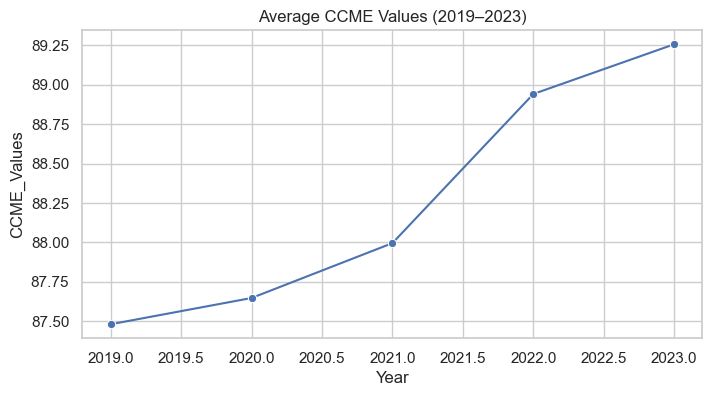

In [31]:
plt.figure(figsize=(8,4))
sns.lineplot(data=filtered_df.groupby('Year')['CCME_Values'].mean().reset_index(),
             x='Year', y='CCME_Values', marker='o')
plt.title("Average CCME Values (2019–2023)")
plt.show()

##### 3.2 Yearly CCME Values by Waterbody Type

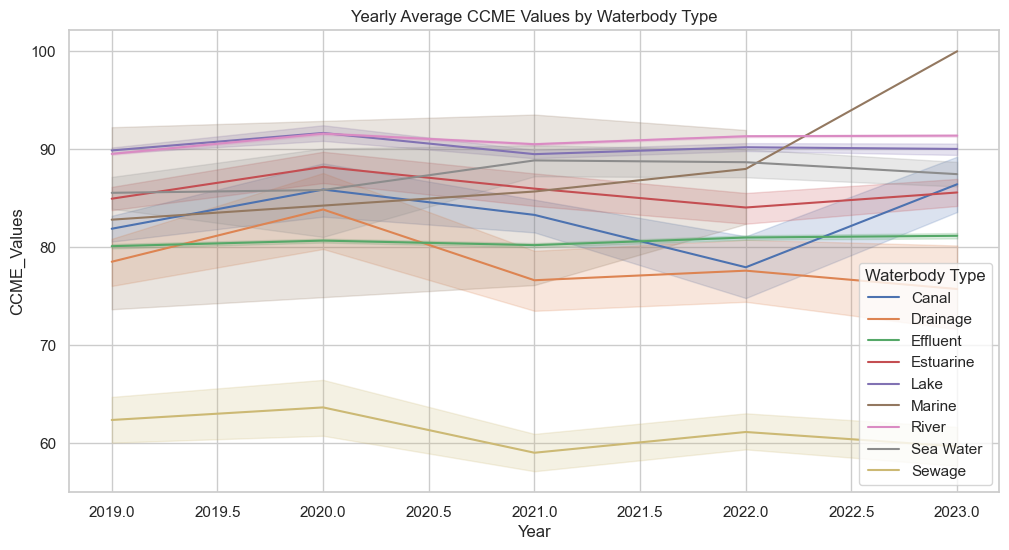

In [32]:
filtered_df['Year'] = filtered_df['Formatted_Date'].dt.year
plt.figure(figsize=(12,6))
sns.lineplot(data=filtered_df, x='Year', y='CCME_Values', hue='Waterbody Type', estimator='mean')
plt.title("Yearly Average CCME Values by Waterbody Type")
plt.show()

##### 3.3 pH trend over time

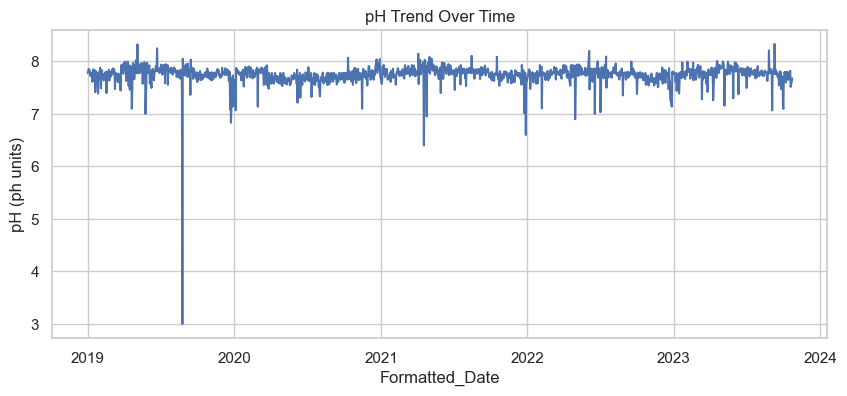

In [33]:
plt.figure(figsize=(10,4))
sns.lineplot(data=filtered_df, x='Formatted_Date', y='pH (ph units)', errorbar=None)
plt.title("pH Trend Over Time")
plt.show()

##### 3.4 Temperature trend over time

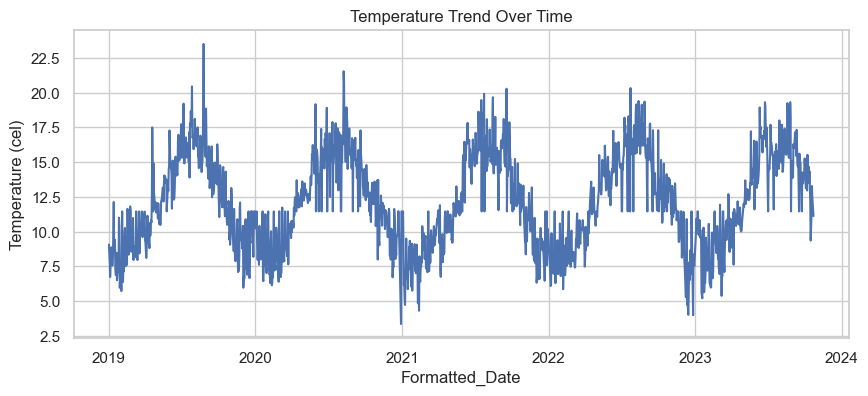

In [34]:
plt.figure(figsize=(10,4))
sns.lineplot(data=filtered_df, x='Formatted_Date', y='Temperature (cel)', errorbar=None)
plt.title("Temperature Trend Over Time")
plt.show()

##### 3.5 Dissolved Oxygen (mg/l) trend over time

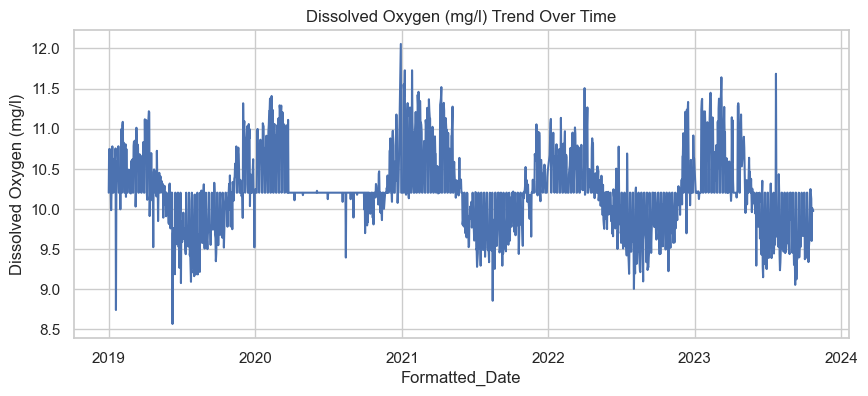

In [35]:
plt.figure(figsize=(10,4))
sns.lineplot(data=filtered_df, x='Formatted_Date', y='Dissolved Oxygen (mg/l)', errorbar=None)
plt.title("Dissolved Oxygen (mg/l) Trend Over Time")
plt.show()

##### 3.6 Ammonia (mg/l) trend over time

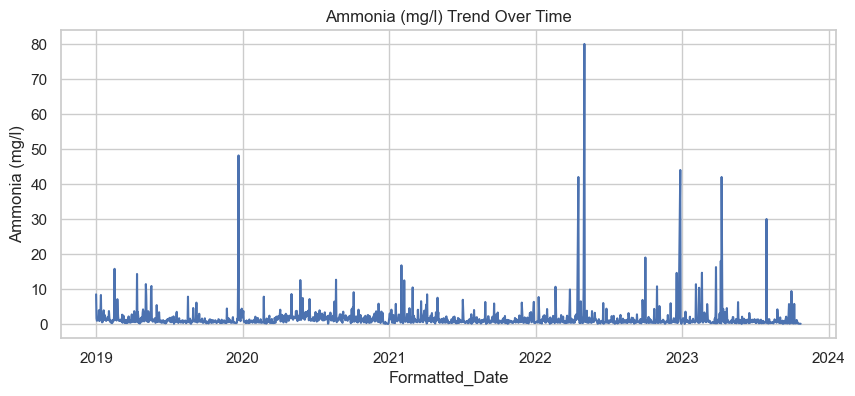

In [36]:
plt.figure(figsize=(10,4))
sns.lineplot(data=filtered_df, x='Formatted_Date', y='Ammonia (mg/l)', errorbar=None)
plt.title("Ammonia (mg/l) Trend Over Time")
plt.show()

##### 3.7 Biochemical Oxygen Demand (mg/l) trend over time

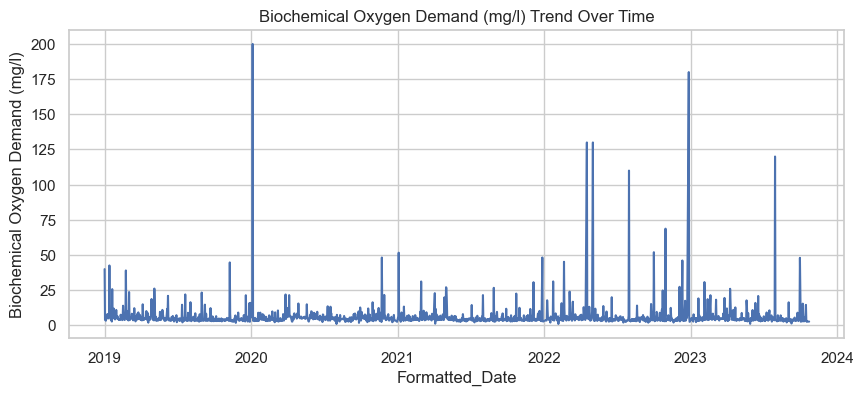

In [37]:
plt.figure(figsize=(10,4))
sns.lineplot(data=filtered_df, x='Formatted_Date', y='Biochemical Oxygen Demand (mg/l)', errorbar=None)
plt.title("Biochemical Oxygen Demand (mg/l) Trend Over Time")
plt.show()

##### 3.8 Orthophosphate (mg/l) Trend Over Time

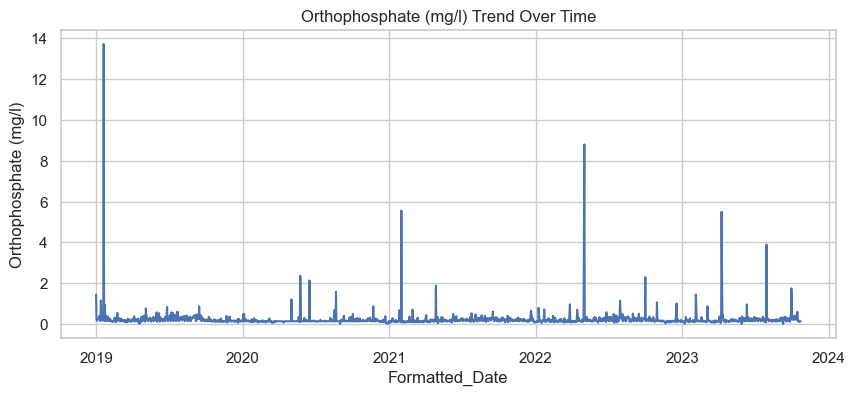

In [38]:
plt.figure(figsize=(10,4))
sns.lineplot(data=filtered_df, x='Formatted_Date', y='Orthophosphate (mg/l)', errorbar=None)
plt.title("Orthophosphate (mg/l) Trend Over Time")
plt.show()

##### 3.9 Nitrogen (mg/l) Trend Over Time

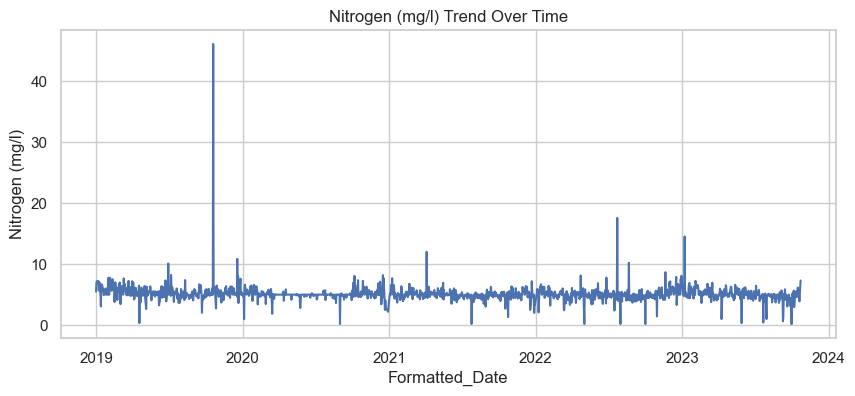

In [39]:
plt.figure(figsize=(10,4))
sns.lineplot(data=filtered_df, x='Formatted_Date', y='Nitrogen (mg/l)', errorbar=None)
plt.title("Nitrogen (mg/l) Trend Over Time")
plt.show()

##### 3.10 Nitrate (mg/l) Trend Over Time

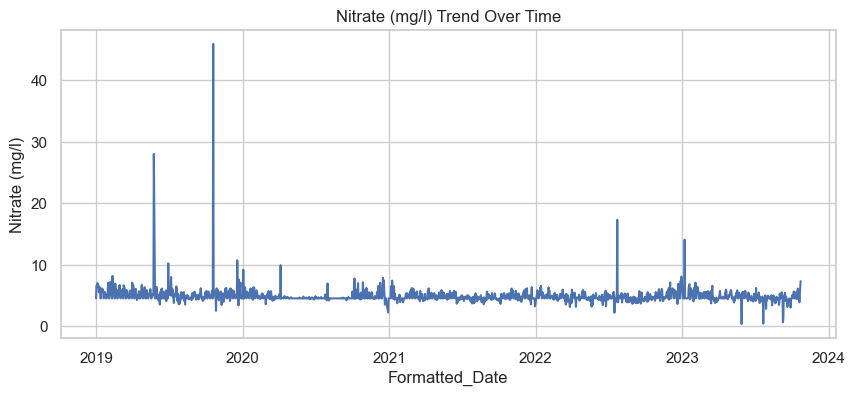

In [40]:
plt.figure(figsize=(10,4))
sns.lineplot(data=filtered_df, x='Formatted_Date', y='Nitrate (mg/l)', errorbar=None)
plt.title("Nitrate (mg/l) Trend Over Time")
plt.show()

## Feature Engineering

#### 1. Time-Based Features

In [41]:
# Ensure datetime format
filtered_df['Formatted_Date'] = pd.to_datetime(filtered_df['Formatted_Date'])

# Extract basic time features
filtered_df['Year'] = filtered_df['Formatted_Date'].dt.year
filtered_df['Month'] = filtered_df['Formatted_Date'].dt.month
filtered_df['Quarter'] = filtered_df['Formatted_Date'].dt.to_period('Q').dt.quarter
filtered_df['DayOfYear'] = filtered_df['Formatted_Date'].dt.dayofyear

# Map months to seasons (Meteorological seasons)
season_map = {12:'Winter', 1:'Winter', 2:'Winter',
              3:'Spring', 4:'Spring', 5:'Spring',
              6:'Summer', 7:'Summer', 8:'Summer',
              9:'Fall',   10:'Fall',  11:'Fall'}
filtered_df['Season'] = filtered_df['Formatted_Date'].dt.month.map(season_map)

#### 2. Interaction Features

In [42]:
# Example interaction features for highly correlated pairs
filtered_df['Ammonia_BOD'] = filtered_df['Ammonia (mg/l)'] * filtered_df['Biochemical Oxygen Demand (mg/l)']
filtered_df['Orthophosphate_Temp'] = filtered_df['Orthophosphate (mg/l)'] * filtered_df['Temperature (cel)']

#### 3. Transformation for Skewed Variables

In [43]:
# Example: log-transform skewed chemical measurements
filtered_df['Ammonia_log'] = np.log1p(filtered_df['Ammonia (mg/l)'])
filtered_df['Orthophosphate_log'] = np.log1p(filtered_df['Orthophosphate (mg/l)'])

# Standardize another skewed measure (e.g. BOD)
scaler = StandardScaler()
filtered_df['BOD_scaled'] = scaler.fit_transform(filtered_df[['Biochemical Oxygen Demand (mg/l)']])

#### 4. Rolling Windows and Lag Features

In [44]:
# Create lag and rolling features for all selected variables
for col in ['pH (ph units)', 'Temperature (cel)', 'Dissolved Oxygen (mg/l)', 'CCME_Values']:
    # Lags
    filtered_df[f'{col}_lag1'] = filtered_df[col].shift(1)
    filtered_df[f'{col}_lag7'] = filtered_df[col].shift(7)
    
    # Rolling statistics
    filtered_df[f'{col}_roll7_mean'] = filtered_df[col].rolling(window=7).mean()
    filtered_df[f'{col}_roll7_std'] = filtered_df[col].rolling(window=7).std()

#### 5. Group-Based Statistical Encoding

In [45]:
# Group by Waterbody Type
group = filtered_df.groupby('Waterbody Type', observed=False)
filtered_df['mean_pH_by_Type'] = group['pH (ph units)'].transform('mean')
filtered_df['std_Temperature_by_Type'] = group['Temperature (cel)'].transform('std')
filtered_df['count_by_Type'] = group['pH (ph units)'].transform('count')

# Group by CCME_WQI
group_wqi = filtered_df.groupby('CCME_WQI', observed=False)
filtered_df['mean_DO_by_WQI'] = group_wqi['Dissolved Oxygen (mg/l)'].transform('mean')

#### 6. Categorical Encoding (One-Hot / Label)

In [46]:
# Make sure you work on a copy
filtered_df = filtered_df.copy()

# One-Hot Encoding for 'Waterbody Type' (keep original)
wb_dummies = pd.get_dummies(filtered_df['Waterbody Type'], prefix='WB', drop_first=False)

# One-Hot Encoding for 'CCME_WQI' (keep original)
wqi_dummies = pd.get_dummies(filtered_df['CCME_WQI'], prefix='WQI', drop_first=False)

# Concatenate encoded features with the original dataframe
filtered_df = pd.concat([filtered_df, wb_dummies, wqi_dummies], axis=1)

#### 7. Seasonal/Anomaly Flags

In [47]:
# Flag pH below 6.5 (acidic anomaly) and DO above 12 mg/L (unusually high)
filtered_df['pH_low_flag'] = (filtered_df['pH (ph units)'] < 6.5).astype(int)
filtered_df['DO_high_flag'] = (filtered_df['Dissolved Oxygen (mg/l)'] > 12).astype(int)

#### 8. Missing/Invalid Data Indicators

In [48]:
# Create missing flags for all columns
for col in filtered_df.columns:
    filtered_df[f'{col}_missing_flag'] = filtered_df[col].isnull().astype(int)

# Example invalid value flags for numeric columns where negatives are impossible
invalid_cols = [
    'Ammonia (mg/l)',
    'Biochemical Oxygen Demand (mg/l)',
    'Dissolved Oxygen (mg/l)',
    'Orthophosphate (mg/l)',
    'pH (ph units)',
    'Temperature (cel)',
    'Nitrogen (mg/l)',
    'Nitrate (mg/l)',
    'CCME_Values'
]

for col in invalid_cols:
    filtered_df[f'{col}_invalid_flag'] = (filtered_df[col] < 0).astype(int)

##### All the column lists after feature engineering

In [49]:
# Check the new shape and columns
print("Shape after encoding:", filtered_df.shape)
print(filtered_df.columns.tolist())

Shape after encoding: (240773, 127)
['Area', 'Waterbody Type', 'Ammonia (mg/l)', 'Biochemical Oxygen Demand (mg/l)', 'Dissolved Oxygen (mg/l)', 'Orthophosphate (mg/l)', 'pH (ph units)', 'Temperature (cel)', 'Nitrogen (mg/l)', 'Nitrate (mg/l)', 'CCME_Values', 'CCME_WQI', 'Formatted_Date', 'Year', 'Month', 'Quarter', 'DayOfYear', 'Season', 'Ammonia_BOD', 'Orthophosphate_Temp', 'Ammonia_log', 'Orthophosphate_log', 'BOD_scaled', 'pH (ph units)_lag1', 'pH (ph units)_lag7', 'pH (ph units)_roll7_mean', 'pH (ph units)_roll7_std', 'Temperature (cel)_lag1', 'Temperature (cel)_lag7', 'Temperature (cel)_roll7_mean', 'Temperature (cel)_roll7_std', 'Dissolved Oxygen (mg/l)_lag1', 'Dissolved Oxygen (mg/l)_lag7', 'Dissolved Oxygen (mg/l)_roll7_mean', 'Dissolved Oxygen (mg/l)_roll7_std', 'CCME_Values_lag1', 'CCME_Values_lag7', 'CCME_Values_roll7_mean', 'CCME_Values_roll7_std', 'mean_pH_by_Type', 'std_Temperature_by_Type', 'count_by_Type', 'mean_DO_by_WQI', 'WB_Canal', 'WB_Drainage', 'WB_Effluent', 'WB_

## Model Development

### Final feature exclusion & leakage-proof feature lists

#### Create a clean modeling dataframe

In [50]:
# Create a clean copy for modeling
df_model = filtered_df.copy()

# Quick sanity check
df_model.shape

(240773, 127)

#### Build GLOBAL exclusion list

In [51]:
# True WQI category dummy columns (target leakage)
wqi_category_cols = [
    'WQI_Excellent',
    'WQI_Good',
    'WQI_Fair',
    'WQI_Marginal',
    'WQI_Poor'
]

# Global exclusions (never used as features)
global_exclude_cols = (
    [
        'Formatted_Date',
        'CCME_Values',
        'CCME_WQI'
    ]
    + wqi_category_cols
    + [
        # Target-derived lag features (excluded for safety)
        'CCME_Values_lag1',
        'CCME_Values_lag7',
        'CCME_Values_roll7_mean',
        'CCME_Values_roll7_std'
    ]
)

# Keep only columns that actually exist in dataframe
global_exclude_cols = [c for c in global_exclude_cols if c in df_model.columns]

global_exclude_cols

['Formatted_Date',
 'CCME_Values',
 'CCME_WQI',
 'WQI_Excellent',
 'WQI_Good',
 'WQI_Fair',
 'WQI_Marginal',
 'WQI_Poor',
 'CCME_Values_lag1',
 'CCME_Values_lag7',
 'CCME_Values_roll7_mean',
 'CCME_Values_roll7_std']

#### Define FINAL feature list

In [52]:
# Final feature columns (leakage-proof)
feature_cols = [col for col in df_model.columns if col not in global_exclude_cols]

# Number of usable features
len(feature_cols)

115

#### Final leakage sanity check

In [53]:
# Safety checks (correct and precise)

# Targets must not be in features
assert 'CCME_Values' not in feature_cols
assert 'CCME_WQI' not in feature_cols

# WQI category dummies must not be in features
assert not any(col in feature_cols for col in wqi_category_cols)

print("Feature list is leakage-proof and correct.")

Feature list is leakage-proof and correct.


### HANDLE NaNs FROM LAG & ROLLING FEATURES

#### Check NaNs (baseline)

In [54]:
# Check total missing values in features
total_missing = df_model[feature_cols].isnull().sum().sum()
total_missing

60

#### Identify which features have NaNs (diagnostic)

In [55]:
# Features with missing values (top 20)
missing_by_feature = (
    df_model[feature_cols]
    .isnull()
    .sum()
    .sort_values(ascending=False)
)

missing_by_feature[missing_by_feature > 0].head(20)

pH (ph units)_lag7                    7
Temperature (cel)_lag7                7
Dissolved Oxygen (mg/l)_lag7          7
Dissolved Oxygen (mg/l)_roll7_std     6
Temperature (cel)_roll7_std           6
pH (ph units)_roll7_mean              6
pH (ph units)_roll7_std               6
Dissolved Oxygen (mg/l)_roll7_mean    6
Temperature (cel)_roll7_mean          6
Temperature (cel)_lag1                1
Dissolved Oxygen (mg/l)_lag1          1
pH (ph units)_lag1                    1
dtype: int64

#### Ensure correct temporal ordering

In [56]:
# Ensure correct temporal order before filling
df_model = df_model.sort_values('Formatted_Date').reset_index(drop=True)

#### Apply forward fill

In [57]:
# Forward fill (time-safe)
df_model[feature_cols] = df_model[feature_cols].ffill()

#### Apply backward fill

In [58]:
# Backward fill for initial rows only
df_model[feature_cols] = df_model[feature_cols].bfill()

#### Final NaN verification

In [59]:
# Final check: no missing values allowed
final_missing = df_model[feature_cols].isnull().sum().sum()
final_missing

0

#### Safety assertion

In [60]:
assert final_missing == 0, "NaNs still present after imputation!"

print("All feature NaNs handled safely.")

All feature NaNs handled safely.


### TEMPORAL TRAIN / VALIDATION / TEST SPLIT

#### Final safety check before splitting

In [61]:
# Final checks before splitting

assert df_model[feature_cols].isnull().sum().sum() == 0, "NaNs found in features!"
assert 'Formatted_Date' in df_model.columns, "Formatted_Date column missing!"

# Ensure datetime type
df_model['Formatted_Date'] = pd.to_datetime(df_model['Formatted_Date'])

print("Pre-split checks passed.")

Pre-split checks passed.


#### Sort by time

In [62]:
# Sort dataset chronologically
df_model = df_model.sort_values('Formatted_Date').reset_index(drop=True)

df_model[['Formatted_Date']].head(), df_model[['Formatted_Date']].tail()

(  Formatted_Date
 0     2019-01-01
 1     2019-01-01
 2     2019-01-01
 3     2019-01-01
 4     2019-01-01,
        Formatted_Date
 240768     2023-10-23
 240769     2023-10-23
 240770     2023-10-23
 240771     2023-10-23
 240772     2023-10-23)

#### Define temporal split boundaries

In [63]:
# Define temporal split boundaries
train_end_date = pd.Timestamp("2022-12-31")
val_end_date   = pd.Timestamp("2023-06-30")

train_end_date, val_end_date

(Timestamp('2022-12-31 00:00:00'), Timestamp('2023-06-30 00:00:00'))

#### Perform the temporal split

In [64]:
# Temporal split
train_df = df_model[df_model['Formatted_Date'] <= train_end_date]
val_df   = df_model[
    (df_model['Formatted_Date'] > train_end_date) &
    (df_model['Formatted_Date'] <= val_end_date)
]
test_df  = df_model[df_model['Formatted_Date'] > val_end_date]

len(train_df), len(val_df), len(test_df)

(197040, 26132, 17601)

#### Verify date ranges

In [65]:
print("Train period:", train_df['Formatted_Date'].min(), "→", train_df['Formatted_Date'].max())
print("Val period:  ", val_df['Formatted_Date'].min(), "→", val_df['Formatted_Date'].max())
print("Test period: ", test_df['Formatted_Date'].min(), "→", test_df['Formatted_Date'].max())

Train period: 2019-01-01 00:00:00 → 2022-12-30 00:00:00
Val period:   2023-01-03 00:00:00 → 2023-06-30 00:00:00
Test period:  2023-07-01 00:00:00 → 2023-10-23 00:00:00


#### Create X (features) for all splits

In [66]:
# Feature matrices
X_train = train_df[feature_cols]
X_val   = val_df[feature_cols]
X_test  = test_df[feature_cols]

X_train.shape, X_val.shape, X_test.shape

((197040, 115), (26132, 115), (17601, 115))

#### Create y targets (all required variants)

In [67]:
# Regression target
y_train_reg = train_df['CCME_Values']
y_val_reg   = val_df['CCME_Values']
y_test_reg  = test_df['CCME_Values']

# Classification target
y_train_clf = train_df['CCME_WQI']
y_val_clf   = val_df['CCME_WQI']
y_test_clf  = test_df['CCME_WQI']

# Anomaly target
if 'InfrastructureAnomaly' in df_model.columns:
    y_train_anom = train_df['InfrastructureAnomaly']
    y_val_anom   = val_df['InfrastructureAnomaly']
    y_test_anom  = test_df['InfrastructureAnomaly']

print("Targets prepared.")

Targets prepared.


#### Hard leakage & overlap assertions

In [68]:
# Index overlap checks
assert set(train_df.index).isdisjoint(val_df.index)
assert set(train_df.index).isdisjoint(test_df.index)
assert set(val_df.index).isdisjoint(test_df.index)

# Target leakage checks
assert 'CCME_Values' not in X_train.columns
assert 'CCME_WQI' not in X_train.columns

print("Temporal split verified. No leakage detected.")

Temporal split verified. No leakage detected.


### PREPROCESSING (FIT ON TRAIN ONLY)

#### Reconfirm feature groups

In [69]:
# Binary features: flags and one-hot encodings
binary_features = [
    col for col in feature_cols
    if col.endswith('_flag')
    or col.endswith('_missing_flag')
    or col.endswith('_invalid_flag')
    or col.startswith('WB_')
]

# Numeric features: everything else
numeric_features = [col for col in feature_cols if col not in binary_features]

# Sanity check on feature groups

print("Numeric features:", len(numeric_features))
print("Binary features: ", len(binary_features))
print("Total features: ", len(feature_cols))

assert len(numeric_features) + len(binary_features) == len(feature_cols)

Numeric features: 36
Binary features:  79
Total features:  115


#### Identify non-numeric columns in X_train

In [70]:
# Identify non-numeric columns mistakenly included
non_numeric_cols = X_train.select_dtypes(include=['object']).columns.tolist()

non_numeric_cols

['Area', 'Season']

#### Update GLOBAL exclusion list

In [71]:
# Add raw categorical / string columns to global exclusion
raw_categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()

global_exclude_cols = list(set(global_exclude_cols + raw_categorical_cols))

#### Rebuild feature columns

In [72]:
# Rebuild feature list safely
feature_cols = [col for col in df_model.columns if col not in global_exclude_cols]

len(feature_cols)

113

#### Recreate X matrices

In [73]:
X_train = X_train[feature_cols]
X_val   = X_val[feature_cols]
X_test  = X_test[feature_cols]

#### Rebuild numeric & binary feature groups SAFELY

In [74]:
# Numeric features (true numeric only)
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Binary features (0/1 flags)
binary_features = [
    col for col in numeric_features
    if X_train[col].nunique() <= 2
]

# Remove binary from numeric
numeric_features = [col for col in numeric_features if col not in binary_features]

print("Numeric features:", len(numeric_features))
print("Binary features: ", len(binary_features))
print("Total features: ", len(feature_cols))

Numeric features: 30
Binary features:  70
Total features:  113


#### Rebuild the preprocessor

In [75]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), numeric_features),
        ('bin', 'passthrough', binary_features)
    ]
)

#### Fit preprocessing

In [76]:
# Fit ONLY on training data
preprocessor.fit(X_train)

,transformers,"[('num', ...), ('bin', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,feature_range,"(0, ...)"
,copy,True
,clip,False


#### Transform train / validation / test sets

In [77]:
# Transform datasets using fitted preprocessor

X_train_processed = preprocessor.transform(X_train)
X_val_processed   = preprocessor.transform(X_val)
X_test_processed  = preprocessor.transform(X_test)

X_train_processed.shape, X_val_processed.shape, X_test_processed.shape

((197040, 100), (26132, 100), (17601, 100))

#### Convert processed arrays to DataFrames

In [78]:
# Get feature names after preprocessing
processed_feature_names = (
    numeric_features + binary_features
)

# Convert to DataFrame for clarity
X_train_processed = pd.DataFrame(
    X_train_processed,
    columns=processed_feature_names,
    index=X_train.index
)

X_val_processed = pd.DataFrame(
    X_val_processed,
    columns=processed_feature_names,
    index=X_val.index
)

X_test_processed = pd.DataFrame(
    X_test_processed,
    columns=processed_feature_names,
    index=X_test.index
)

X_train_processed.head()

,Ammonia (mg/l),Biochemical Oxygen Demand (mg/l),Dissolved Oxygen (mg/l),Orthophosphate (mg/l),pH (ph units),Temperature (cel),Nitrogen (mg/l),Nitrate (mg/l),Quarter,Ammonia_BOD,...,DO_high_flag_missing_flag,Ammonia (mg/l)_invalid_flag,Biochemical Oxygen Demand (mg/l)_invalid_flag,Dissolved Oxygen (mg/l)_invalid_flag,Orthophosphate (mg/l)_invalid_flag,pH (ph units)_invalid_flag,Temperature (cel)_invalid_flag,Nitrogen (mg/l)_invalid_flag,Nitrate (mg/l)_invalid_flag,CCME_Values_invalid_flag
0,0.11700,0.596078,0.512563,0.041890,0.552581,0.118880,0.004348,0.032847,0.0,0.074880,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.10650,0.400000,0.512563,0.036842,0.552581,0.086100,0.004348,0.032847,0.0,0.045739,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.02015,0.049020,0.512563,0.005317,0.552581,0.092324,0.083261,0.032847,0.0,0.001061,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.02545,0.016392,0.512563,0.008378,0.552581,0.086100,0.045870,0.032847,0.0,0.000448,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.02550,0.014039,0.512563,0.007820,0.552581,0.085062,0.031739,0.032847,0.0,0.000384,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


#### Final preprocessing validation

In [79]:
# No NaNs after preprocessing
assert X_train_processed.isnull().sum().sum() == 0
assert X_val_processed.isnull().sum().sum() == 0
assert X_test_processed.isnull().sum().sum() == 0

# Check scaling range for numeric features
X_train_processed[numeric_features].describe().loc[['min', 'max']]

,Ammonia (mg/l),Biochemical Oxygen Demand (mg/l),Dissolved Oxygen (mg/l),Orthophosphate (mg/l),pH (ph units),Temperature (cel),Nitrogen (mg/l),Nitrate (mg/l),Quarter,Ammonia_BOD,...,Temperature (cel)_roll7_mean,Temperature (cel)_roll7_std,Dissolved Oxygen (mg/l)_lag1,Dissolved Oxygen (mg/l)_lag7,Dissolved Oxygen (mg/l)_roll7_mean,Dissolved Oxygen (mg/l)_roll7_std,mean_pH_by_Type,std_Temperature_by_Type,count_by_Type,mean_DO_by_WQI
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


### XGBoost Regression (CCME_Values)

#### Import required libraries

In [80]:
import xgboost as xgb

from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

#### Initialize the XGBoost Regressor

In [81]:
xgb_reg = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

#### Train the model

In [82]:
xgb_reg.fit(
    X_train_processed,
    y_train_reg
)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None
,feature_types,None


#### Validate the model (VALIDATION set)

In [83]:
# Validation predictions
y_val_pred = xgb_reg.predict(X_val_processed)

# Validation metrics
r2_val = r2_score(y_val_reg, y_val_pred)
rmse_val = np.sqrt(mean_squared_error(y_val_reg, y_val_pred))
mae_val = mean_absolute_error(y_val_reg, y_val_pred)

print("Validation Performance (Model 1 - XGBoost Regression)")
print(f"R²   : {r2_val:.4f}")
print(f"RMSE : {rmse_val:.4f}")
print(f"MAE  : {mae_val:.4f}")

Validation Performance (Model 1 - XGBoost Regression)
R²   : 0.9997
RMSE : 0.2107
MAE  : 0.0734


#### Final evaluation on TEST set

In [84]:
# Test predictions
y_test_pred = xgb_reg.predict(X_test_processed)

# Test metrics
r2_test = r2_score(y_test_reg, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test_reg, y_test_pred))
mae_test = mean_absolute_error(y_test_reg, y_test_pred)

print("Test Performance (Model 1 - XGBoost Regression)")
print(f"R²   : {r2_test:.4f}")
print(f"RMSE : {rmse_test:.4f}")
print(f"MAE  : {mae_test:.4f}")

Test Performance (Model 1 - XGBoost Regression)
R²   : 0.9998
RMSE : 0.1827
MAE  : 0.0622


#### Mandatory sanity checks

In [85]:
print("Train samples:", X_train_processed.shape[0])
print("Val samples  :", X_val_processed.shape[0])
print("Test samples :", X_test_processed.shape[0])

Train samples: 197040
Val samples  : 26132
Test samples : 17601


#### Save Model 1: XGBoost Regression

In [86]:
# === Save Model 1: XGBoost Regression (safe re-save) ===
import joblib, os
os.makedirs("models", exist_ok=True)

# xgb_reg is the trained regressor variable in your notebook
joblib.dump(xgb_reg, "models/xgb_regression.joblib", compress=3)

print("Saved xgb_regression.joblib → models/xgb_regression.joblib")

Saved xgb_regression.joblib → models/xgb_regression.joblib


### SHAP Explainability for XGBoost (CCME_Values Regression)

#### Import SHAP with initjs

In [87]:
import shap
shap.initjs()
import numpy as np
import matplotlib.pyplot as plt

In [88]:
# Initialize SHAP explainer
explainer = shap.TreeExplainer(xgb_reg)

#### Compute and Check SHAP values (use TEST set)

In [89]:
# Compute SHAP values for test data
shap_values = explainer.shap_values(X_test_processed)

In [90]:
print("SHAP values shape:", shap_values.shape)
print("Test data shape :", X_test_processed.shape)

SHAP values shape: (17601, 100)
Test data shape : (17601, 100)


#### SHAP Summary Plot (Bar)

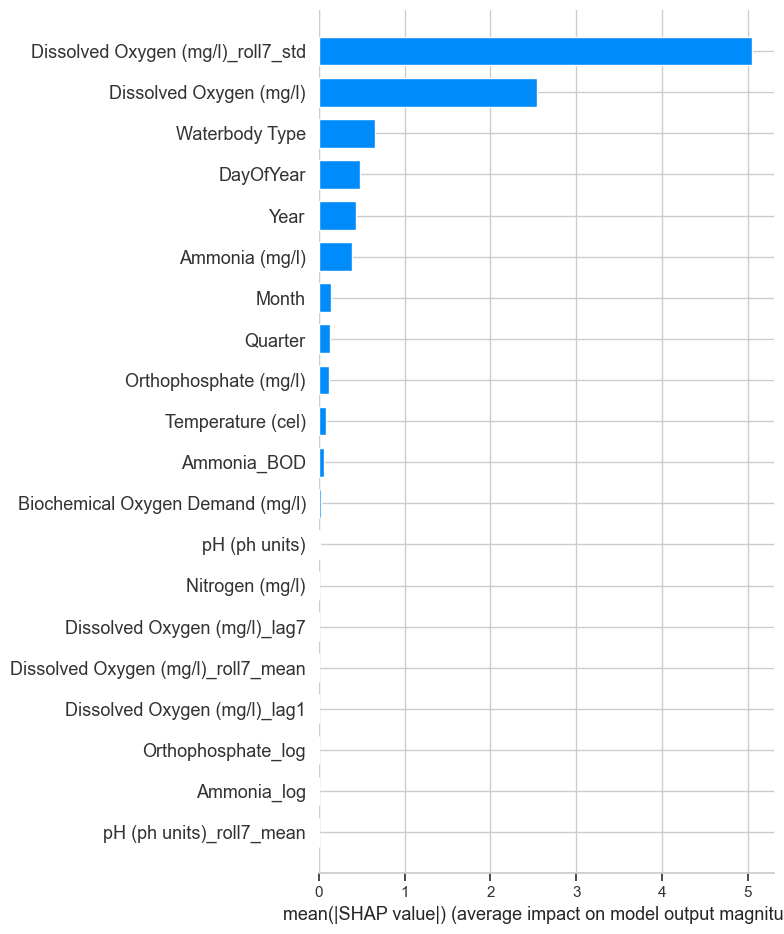

In [91]:
shap.summary_plot(
    shap_values,
    X_test_processed,
    feature_names=feature_cols,
    plot_type="bar",
    show=True
)

#### Detailed Impact Distribution (Beeswarm Plot)

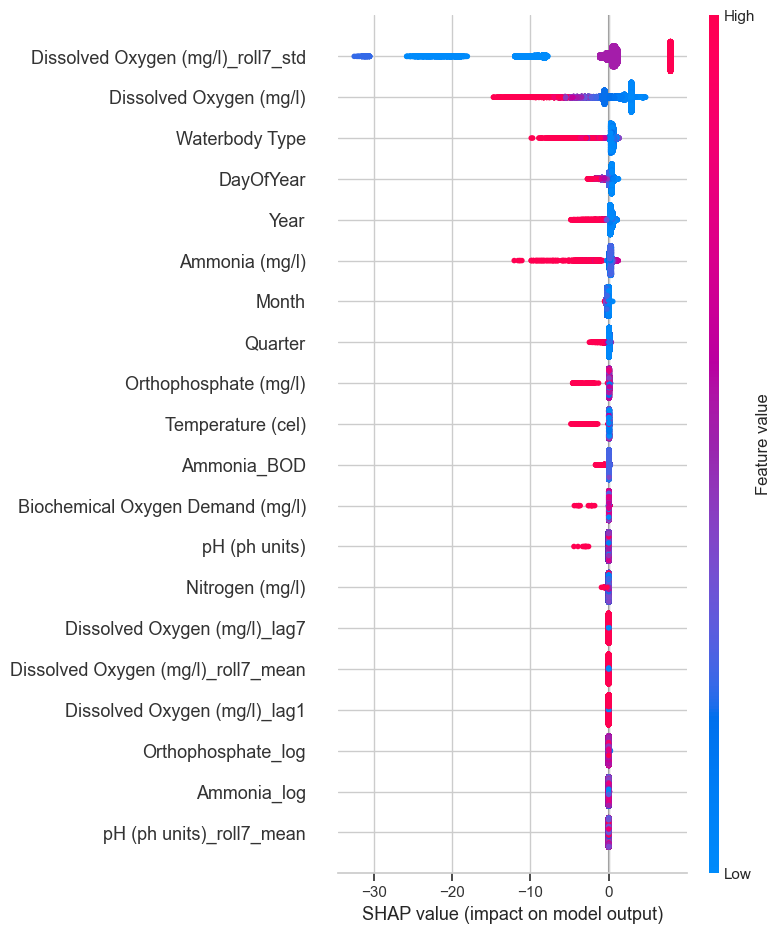

In [92]:
shap.summary_plot(
    shap_values,
    X_test_processed,
    feature_names=feature_cols,
    show=True
)

#### Explain Individual Predictions (Force Plot)

In [93]:
explainer = shap.Explainer(xgb_reg, X_train_processed)
shap_values = explainer(X_test_processed)

 99%|===================| 17420/17601 [01:25<00:00]        

#### Explain High CCME Value

In [94]:
idx = y_test_reg.values.argmax()

In [95]:
shap.plots.force(shap_values[idx])

#### Explain Low CCME Value

In [96]:
idx = y_test_reg.values.argmin()

In [97]:
shap.plots.force(shap_values[idx])

#### Save SHAP plots for dissertation

In [98]:
plt.figure()
shap.summary_plot(
    shap_values,
    X_test_processed,
    feature_names=feature_cols,
    plot_type="bar",
    show=False
)
plt.savefig("shap_model1_feature_importance.png", dpi=300, bbox_inches="tight")
plt.close()

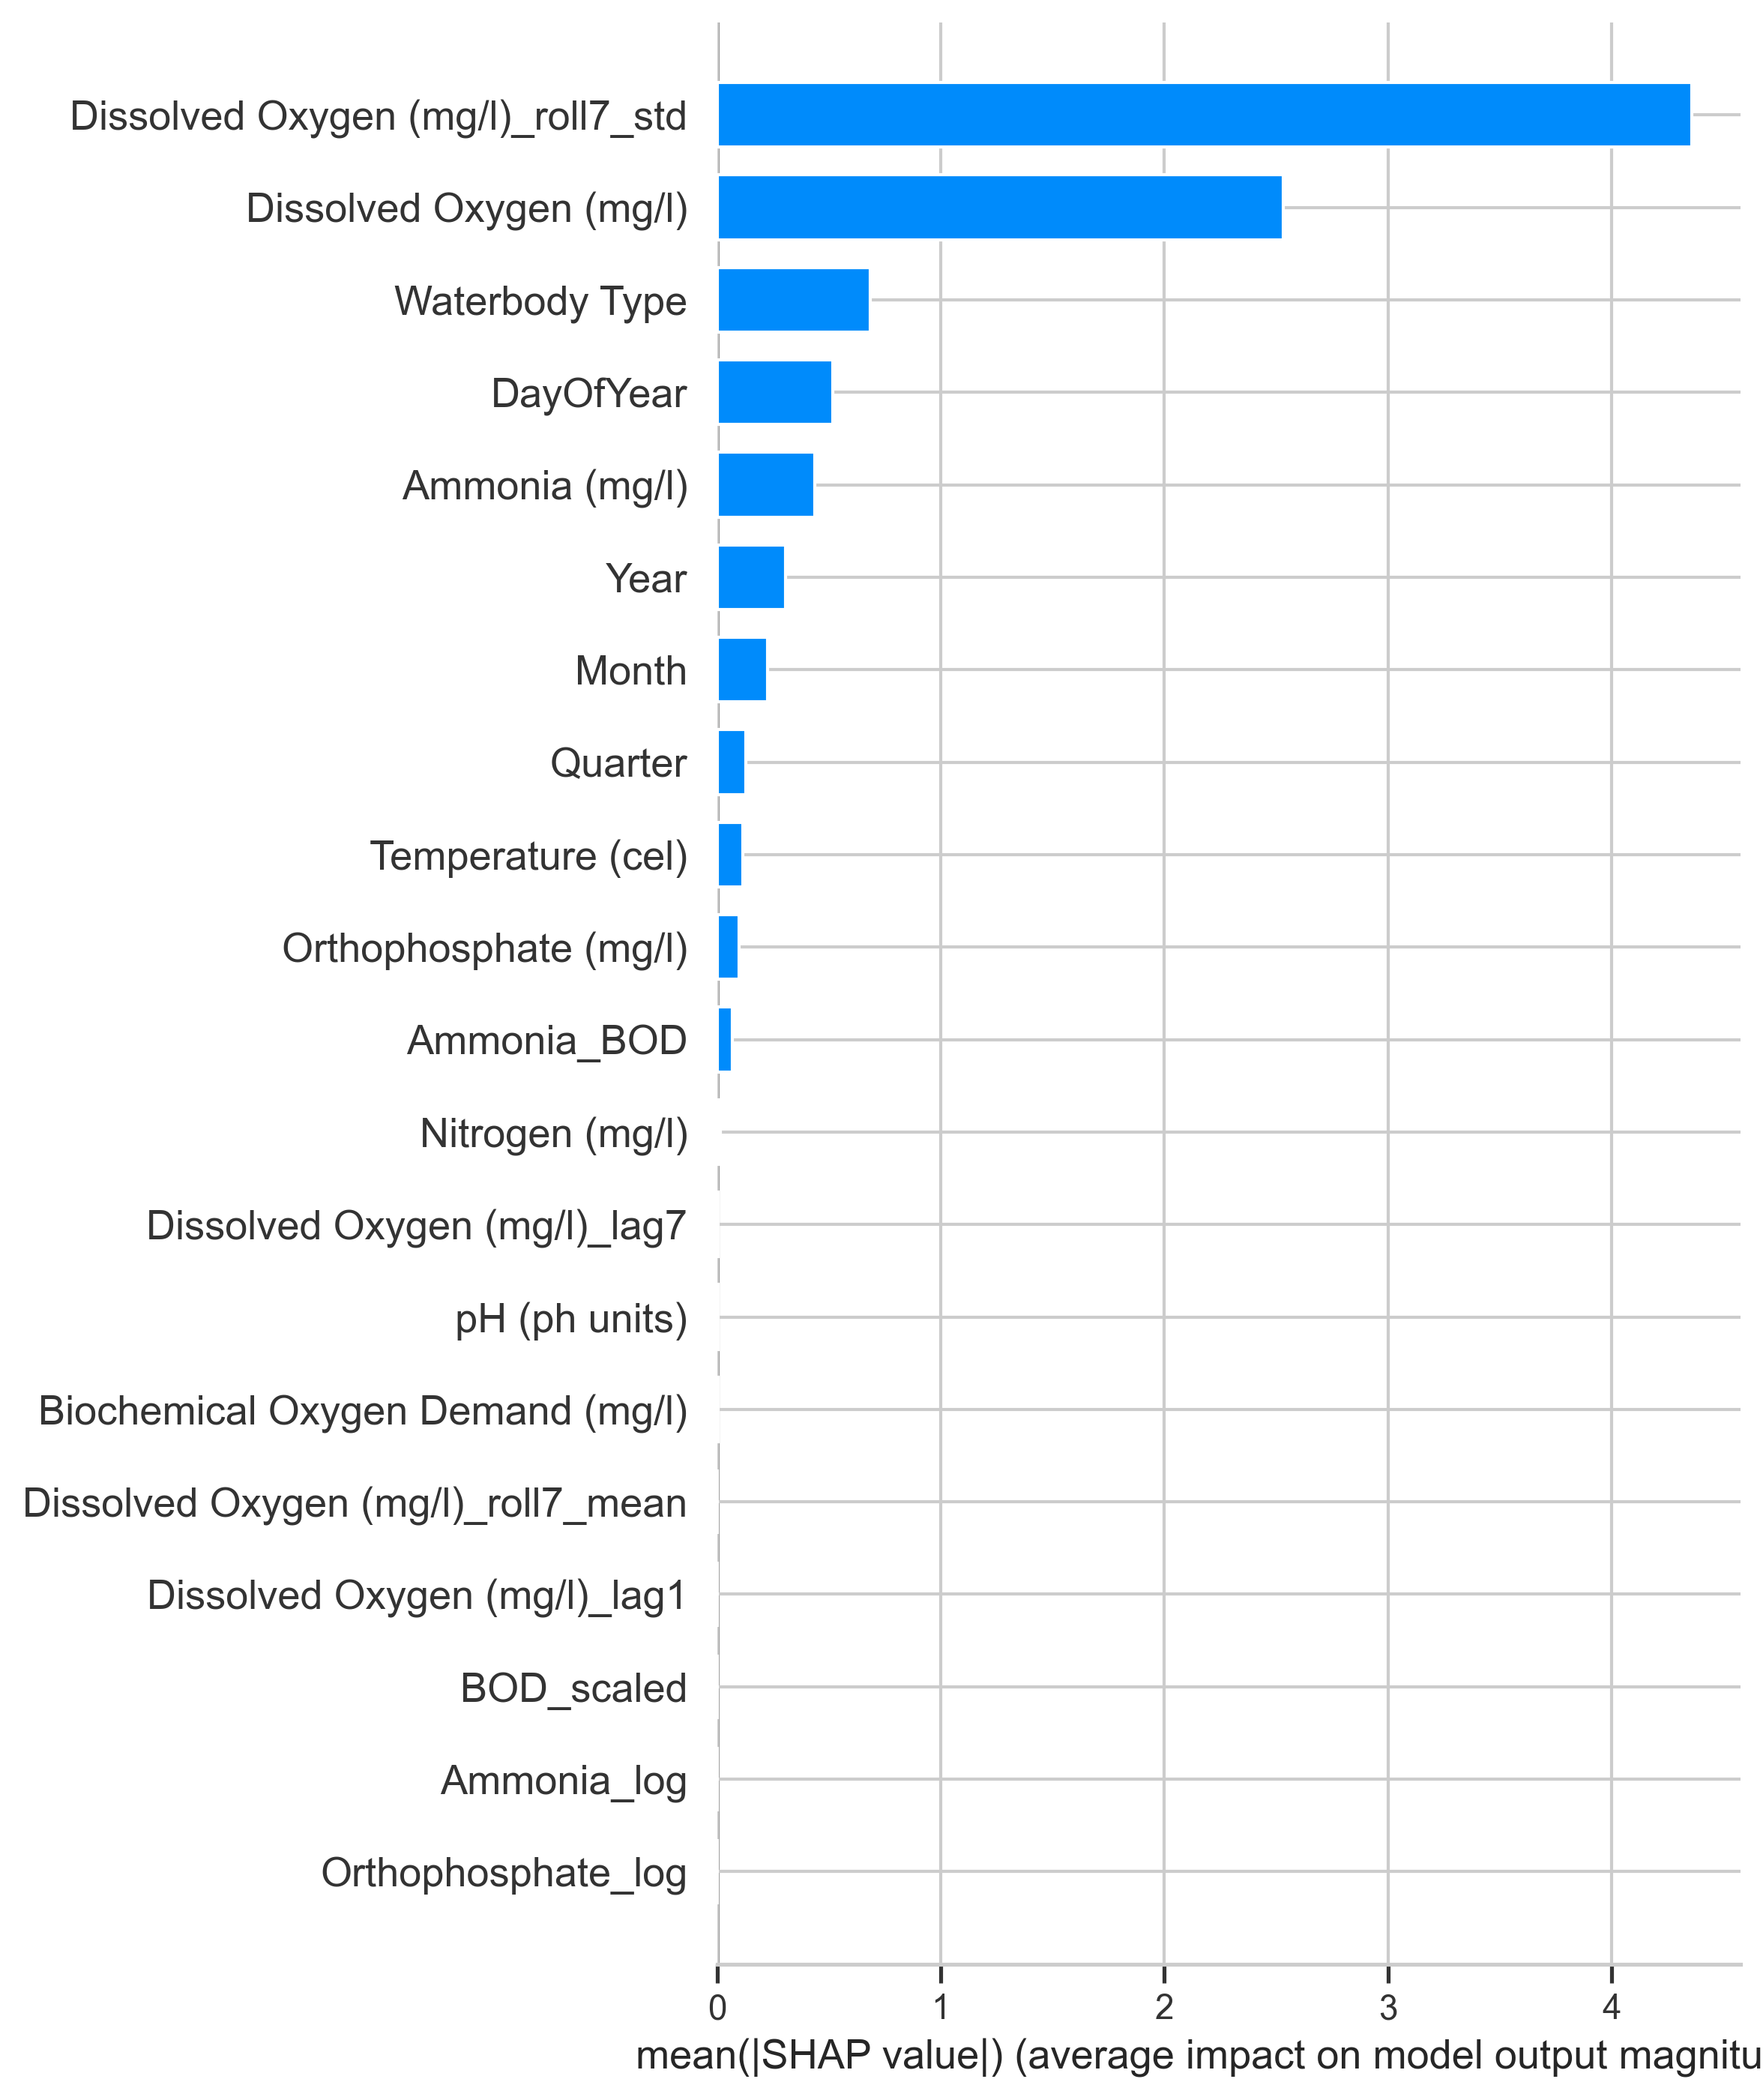

In [99]:
from IPython.display import Image, display
display(Image(filename="shap_model1_feature_importance.png"))

### XGBoost Classification (CCME_WQI)

#### Target preparation (Check the CCME_WQI values)

In [100]:
df_model['CCME_WQI'].value_counts()

CCME_WQI
Good         124034
Excellent     70901
Fair          31326
Marginal      13124
Poor           1388
Name: count, dtype: int64

#### Encode CCME_WQI into numeric labels

In [101]:
# Raw classification labels
y_train_cls_raw = train_df['CCME_WQI']
y_val_cls_raw   = val_df['CCME_WQI']
y_test_cls_raw  = test_df['CCME_WQI']

from sklearn.preprocessing import LabelEncoder

# Initialize encoder
wqi_encoder = LabelEncoder()

# Fit ONLY on training labels
y_train_cls = wqi_encoder.fit_transform(y_train_cls_raw)
y_val_cls   = wqi_encoder.transform(y_val_cls_raw)
y_test_cls  = wqi_encoder.transform(y_test_cls_raw)

# Check mapping
class_mapping = dict(
    zip(wqi_encoder.classes_,
        wqi_encoder.transform(wqi_encoder.classes_))
)

class_mapping

{'Excellent': 0, 'Fair': 1, 'Good': 2, 'Marginal': 3, 'Poor': 4}

#### Import classification metrics

In [102]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

#### Initialize XGBoost Classifier

In [103]:
xgb_clf = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=len(wqi_encoder.classes_),
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

#### Train the classifier (TRAIN set only)

In [104]:
xgb_clf.fit(
    X_train_processed,
    y_train_cls
)

,objective,'multi:softprob'
,use_label_encoder,None
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


#### Validation performance

In [105]:
# Validation predictions
y_val_pred = xgb_clf.predict(X_val_processed)

# Metrics
val_accuracy = accuracy_score(y_val_cls, y_val_pred)
val_f1 = f1_score(y_val_cls, y_val_pred, average='weighted')

print("Validation Performance (Model 2 - XGBoost Classification)")
print(f"Accuracy : {val_accuracy:.4f}")
print(f"F1-score : {val_f1:.4f}")

Validation Performance (Model 2 - XGBoost Classification)
Accuracy : 1.0000
F1-score : 1.0000


#### Final TEST evaluation

In [106]:
# Test predictions
y_test_pred = xgb_clf.predict(X_test_processed)

# Test metrics
test_accuracy = accuracy_score(y_test_cls, y_test_pred)
test_f1 = f1_score(y_test_cls, y_test_pred, average='weighted')

print("Test Performance (Model 2 - XGBoost Classification)")
print(f"Accuracy : {test_accuracy:.4f}")
print(f"F1-score : {test_f1:.4f}")

Test Performance (Model 2 - XGBoost Classification)
Accuracy : 1.0000
F1-score : 1.0000


#### Confusion Matrix

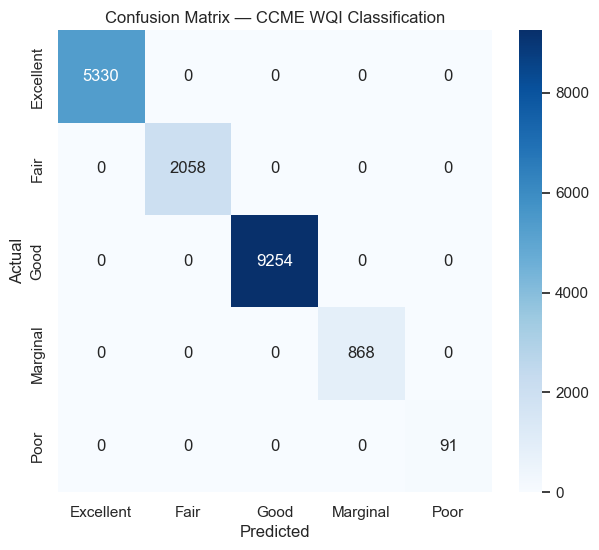

In [107]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_cls, y_test_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=wqi_encoder.classes_,
    yticklabels=wqi_encoder.classes_
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — CCME WQI Classification")
plt.show()

#### Detailed classification report

In [108]:
print(
    classification_report(
        y_test_cls,
        y_test_pred,
        target_names=wqi_encoder.classes_
    )
)

              precision    recall  f1-score   support

   Excellent       1.00      1.00      1.00      5330
        Fair       1.00      1.00      1.00      2058
        Good       1.00      1.00      1.00      9254
    Marginal       1.00      1.00      1.00       868
        Poor       1.00      1.00      1.00        91

    accuracy                           1.00     17601
   macro avg       1.00      1.00      1.00     17601
weighted avg       1.00      1.00      1.00     17601



#### Save Model 2: XGBoost Classification

In [109]:
# === Save Model 2: XGBoost Classifier + Label Encoder ===
import joblib, os
os.makedirs("models", exist_ok=True)

# Save classifier (variable: xgb_clf)
joblib.dump(xgb_clf, "models/xgb_classification.joblib", compress=3)

# Save label encoder (variable: wqi_encoder)
if 'wqi_encoder' in globals():
    joblib.dump(wqi_encoder, "models/wqi_label_encoder.joblib", compress=3)
    print("Saved label encoder to models/wqi_label_encoder.joblib")
else:
    print("wqi_encoder not found in globals(); skip saving encoder")

print("Saved xgb classifier to models/xgb_classification.joblib")

Saved label encoder to models/wqi_label_encoder.joblib
Saved xgb classifier to models/xgb_classification.joblib


### SHAP Explainability for XGBoost (CCME_WQI Classifier)

#### Create SHAP TreeExplainer for the classifier

In [110]:
explainer_clf = shap.TreeExplainer(xgb_clf)

#### Compute SHAP values (use TEST set only)

In [111]:
# Compute SHAP values for classification
shap_values_clf = explainer_clf.shap_values(X_test_processed)

type(shap_values_clf), len(shap_values_clf)

(numpy.ndarray, 17601)

#### Verify SHAP dimensions (sanity check)

In [112]:
for i, class_name in enumerate(wqi_encoder.classes_):
    print(
        f"Class '{class_name}' SHAP shape:",
        shap_values_clf[i].shape
    )

Class 'Excellent' SHAP shape: (100, 5)
Class 'Fair' SHAP shape: (100, 5)
Class 'Good' SHAP shape: (100, 5)
Class 'Marginal' SHAP shape: (100, 5)
Class 'Poor' SHAP shape: (100, 5)


#### Focus on critical classes (Poor)

In [113]:
# Example: suppose your classes are
class_names = ['Excellent', 'Fair', 'Good', 'Marginal', 'Poor']

# Create dictionary mapping class name to index
class_to_index = {name: idx for idx, name in enumerate(class_names)}

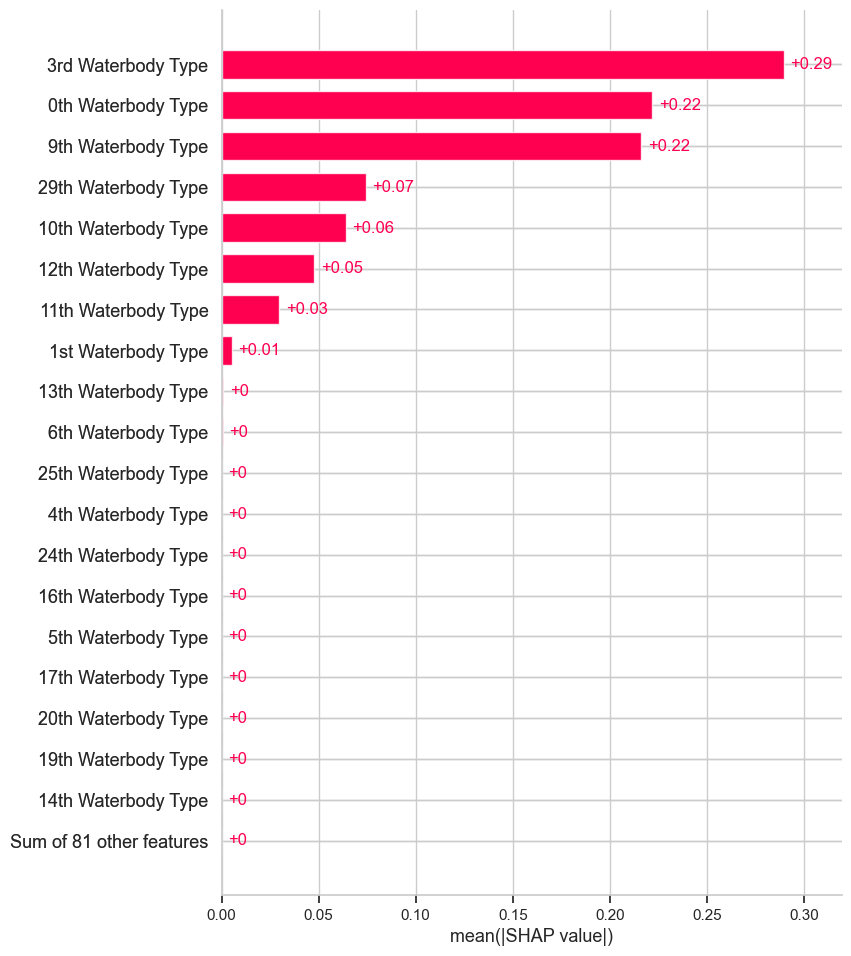

In [114]:
poor_idx = class_to_index['Poor']

shap_values_poor = shap.Explanation(
    values=shap_values_clf[:, :, poor_idx],
    base_values=np.repeat(
        explainer.expected_value,
        shap_values_clf.shape[0]
    ),
    data=X_test_processed.values
    if hasattr(X_test_processed, "values") else X_test_processed,
    feature_names=feature_cols
)

# Global feature importance for Poor class
shap.plots.bar(shap_values_poor, max_display=20)

#### Focus on critical classes (Marginal)

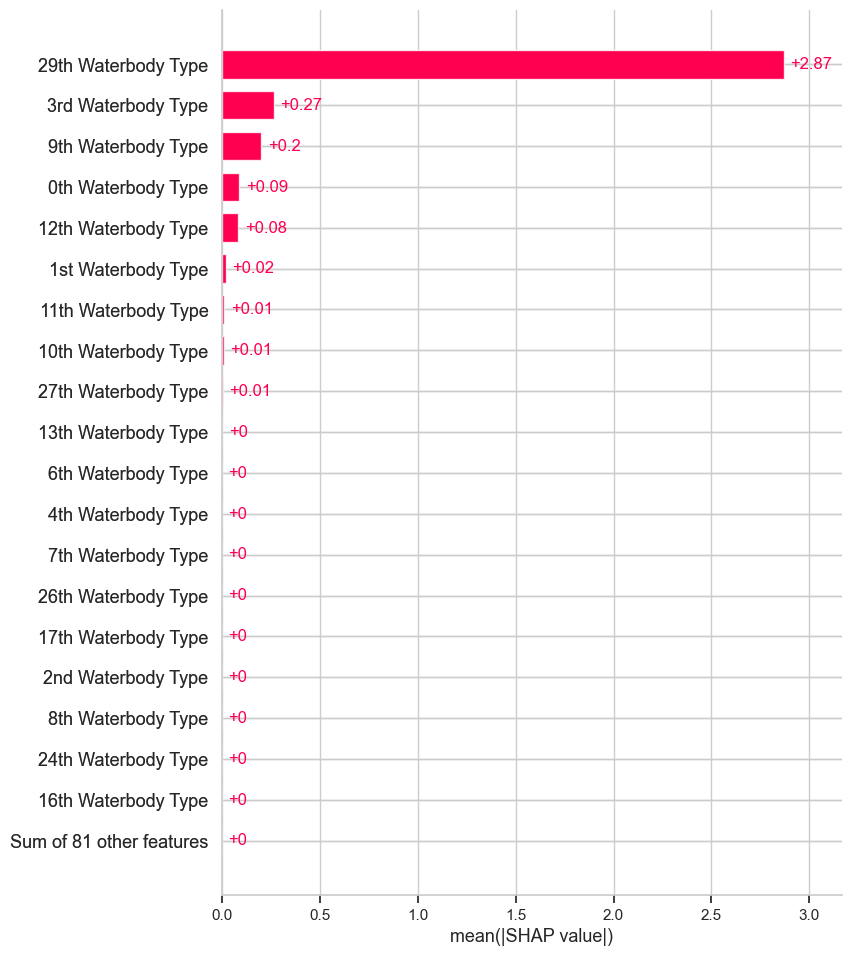

In [115]:
marginal_idx = class_to_index['Marginal']

shap_values_marginal = shap.Explanation(
    values=shap_values_clf[:, :, marginal_idx],
    base_values=np.repeat(
        explainer.expected_value,
        shap_values_clf.shape[0]
    ),
    data=X_test_processed.values
    if hasattr(X_test_processed, "values") else X_test_processed,
    feature_names=feature_cols
)

# Global feature importance for Marginal class
shap.plots.bar(shap_values_marginal, max_display=20)

#### Modern SHAP API (Poor)

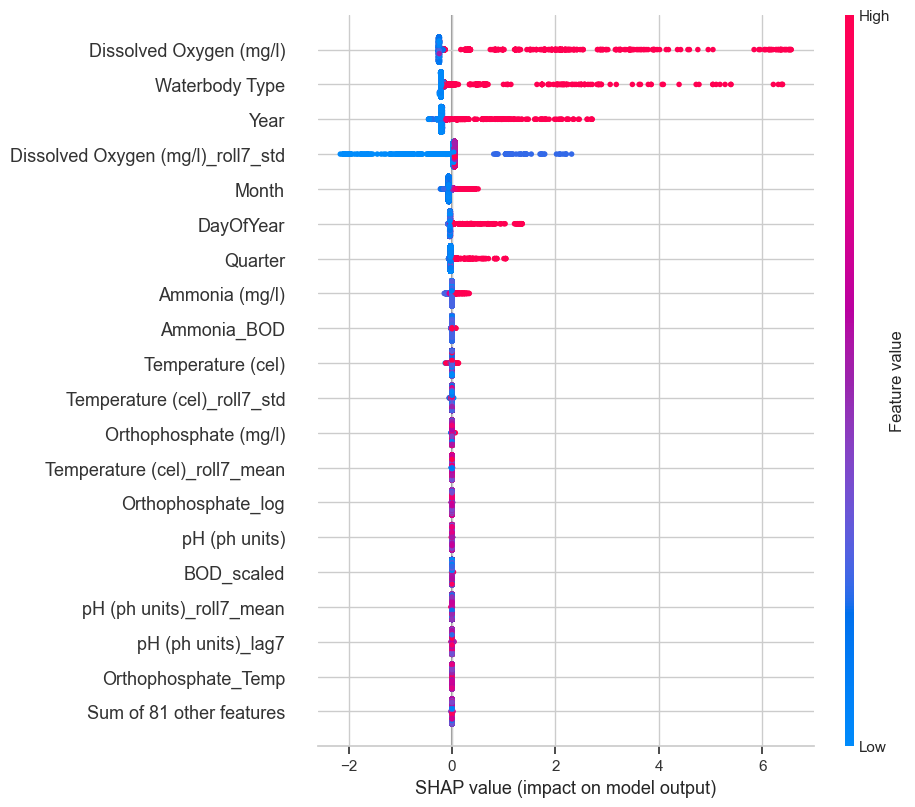

In [116]:
poor_idx = class_to_index['Poor']

shap_values_poor = shap.Explanation(
    values=shap_values_clf[:, :, poor_idx],
    base_values=np.repeat(
        explainer.expected_value,
        shap_values_clf.shape[0]
    ),
    data=X_test_processed.values
    if hasattr(X_test_processed, "values") else X_test_processed,
    feature_names=feature_cols
)

shap.plots.beeswarm(shap_values_poor, max_display=20)

#### Individual Prediction Explanation (Force Plot) - Poor

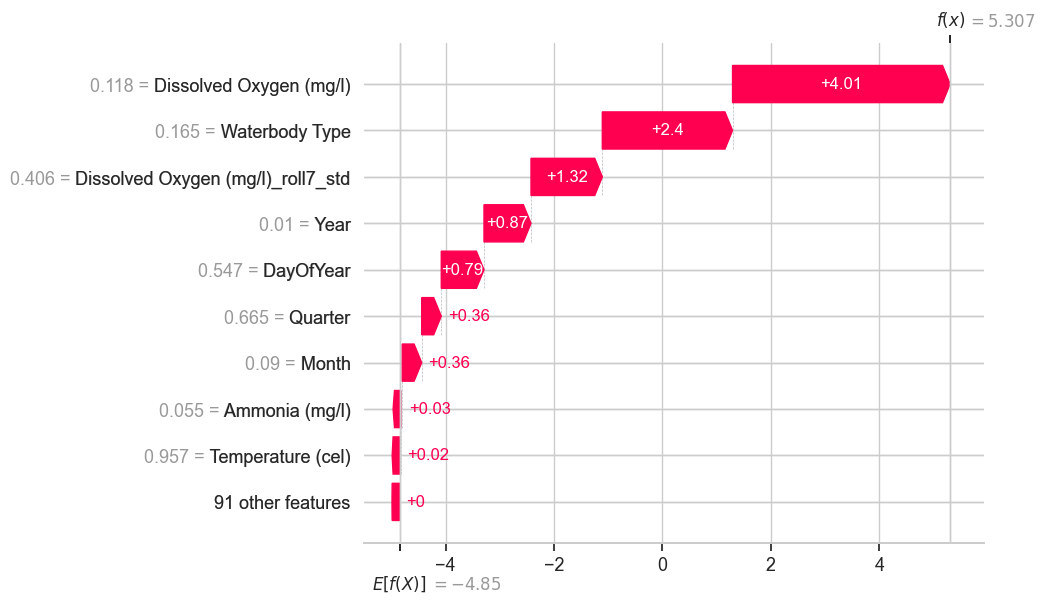

In [117]:
shap_exp_single = shap.Explanation(
    values=shap_values_clf[idx, :, poor_idx],
    base_values=explainer_clf.expected_value[poor_idx],  # MUST be scalar
    data=X_test_processed.iloc[idx].values,
    feature_names=feature_cols
)

shap.plots.waterfall(shap_exp_single)

#### Individual Prediction Explanation (Force Plot) - Excellent

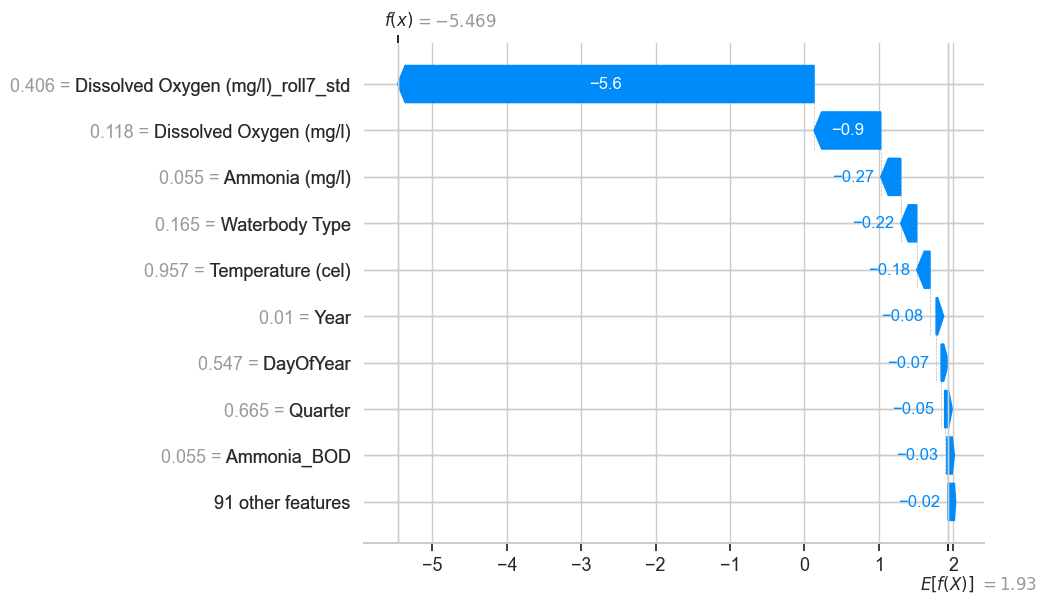

In [118]:
excellent_idx = class_to_index['Excellent']

shap_exp_single = shap.Explanation(
    values=shap_values_clf[idx, :, excellent_idx],
    base_values=explainer_clf.expected_value[excellent_idx],  # MUST be scalar
    data=X_test_processed.iloc[idx].values,
    feature_names=feature_cols
)

shap.plots.waterfall(shap_exp_single)

#### Save SHAP plots (for dissertation) - Poor

In [119]:
plt.figure()
shap.summary_plot(
    shap_values_clf[:, :, poor_idx],   # ✅ correct slicing
    X_test_processed,
    feature_names=feature_cols,
    plot_type="bar",
    show=False
)
plt.savefig("shap_model2_poor_class_importance.png", dpi=300, bbox_inches="tight")
plt.close()

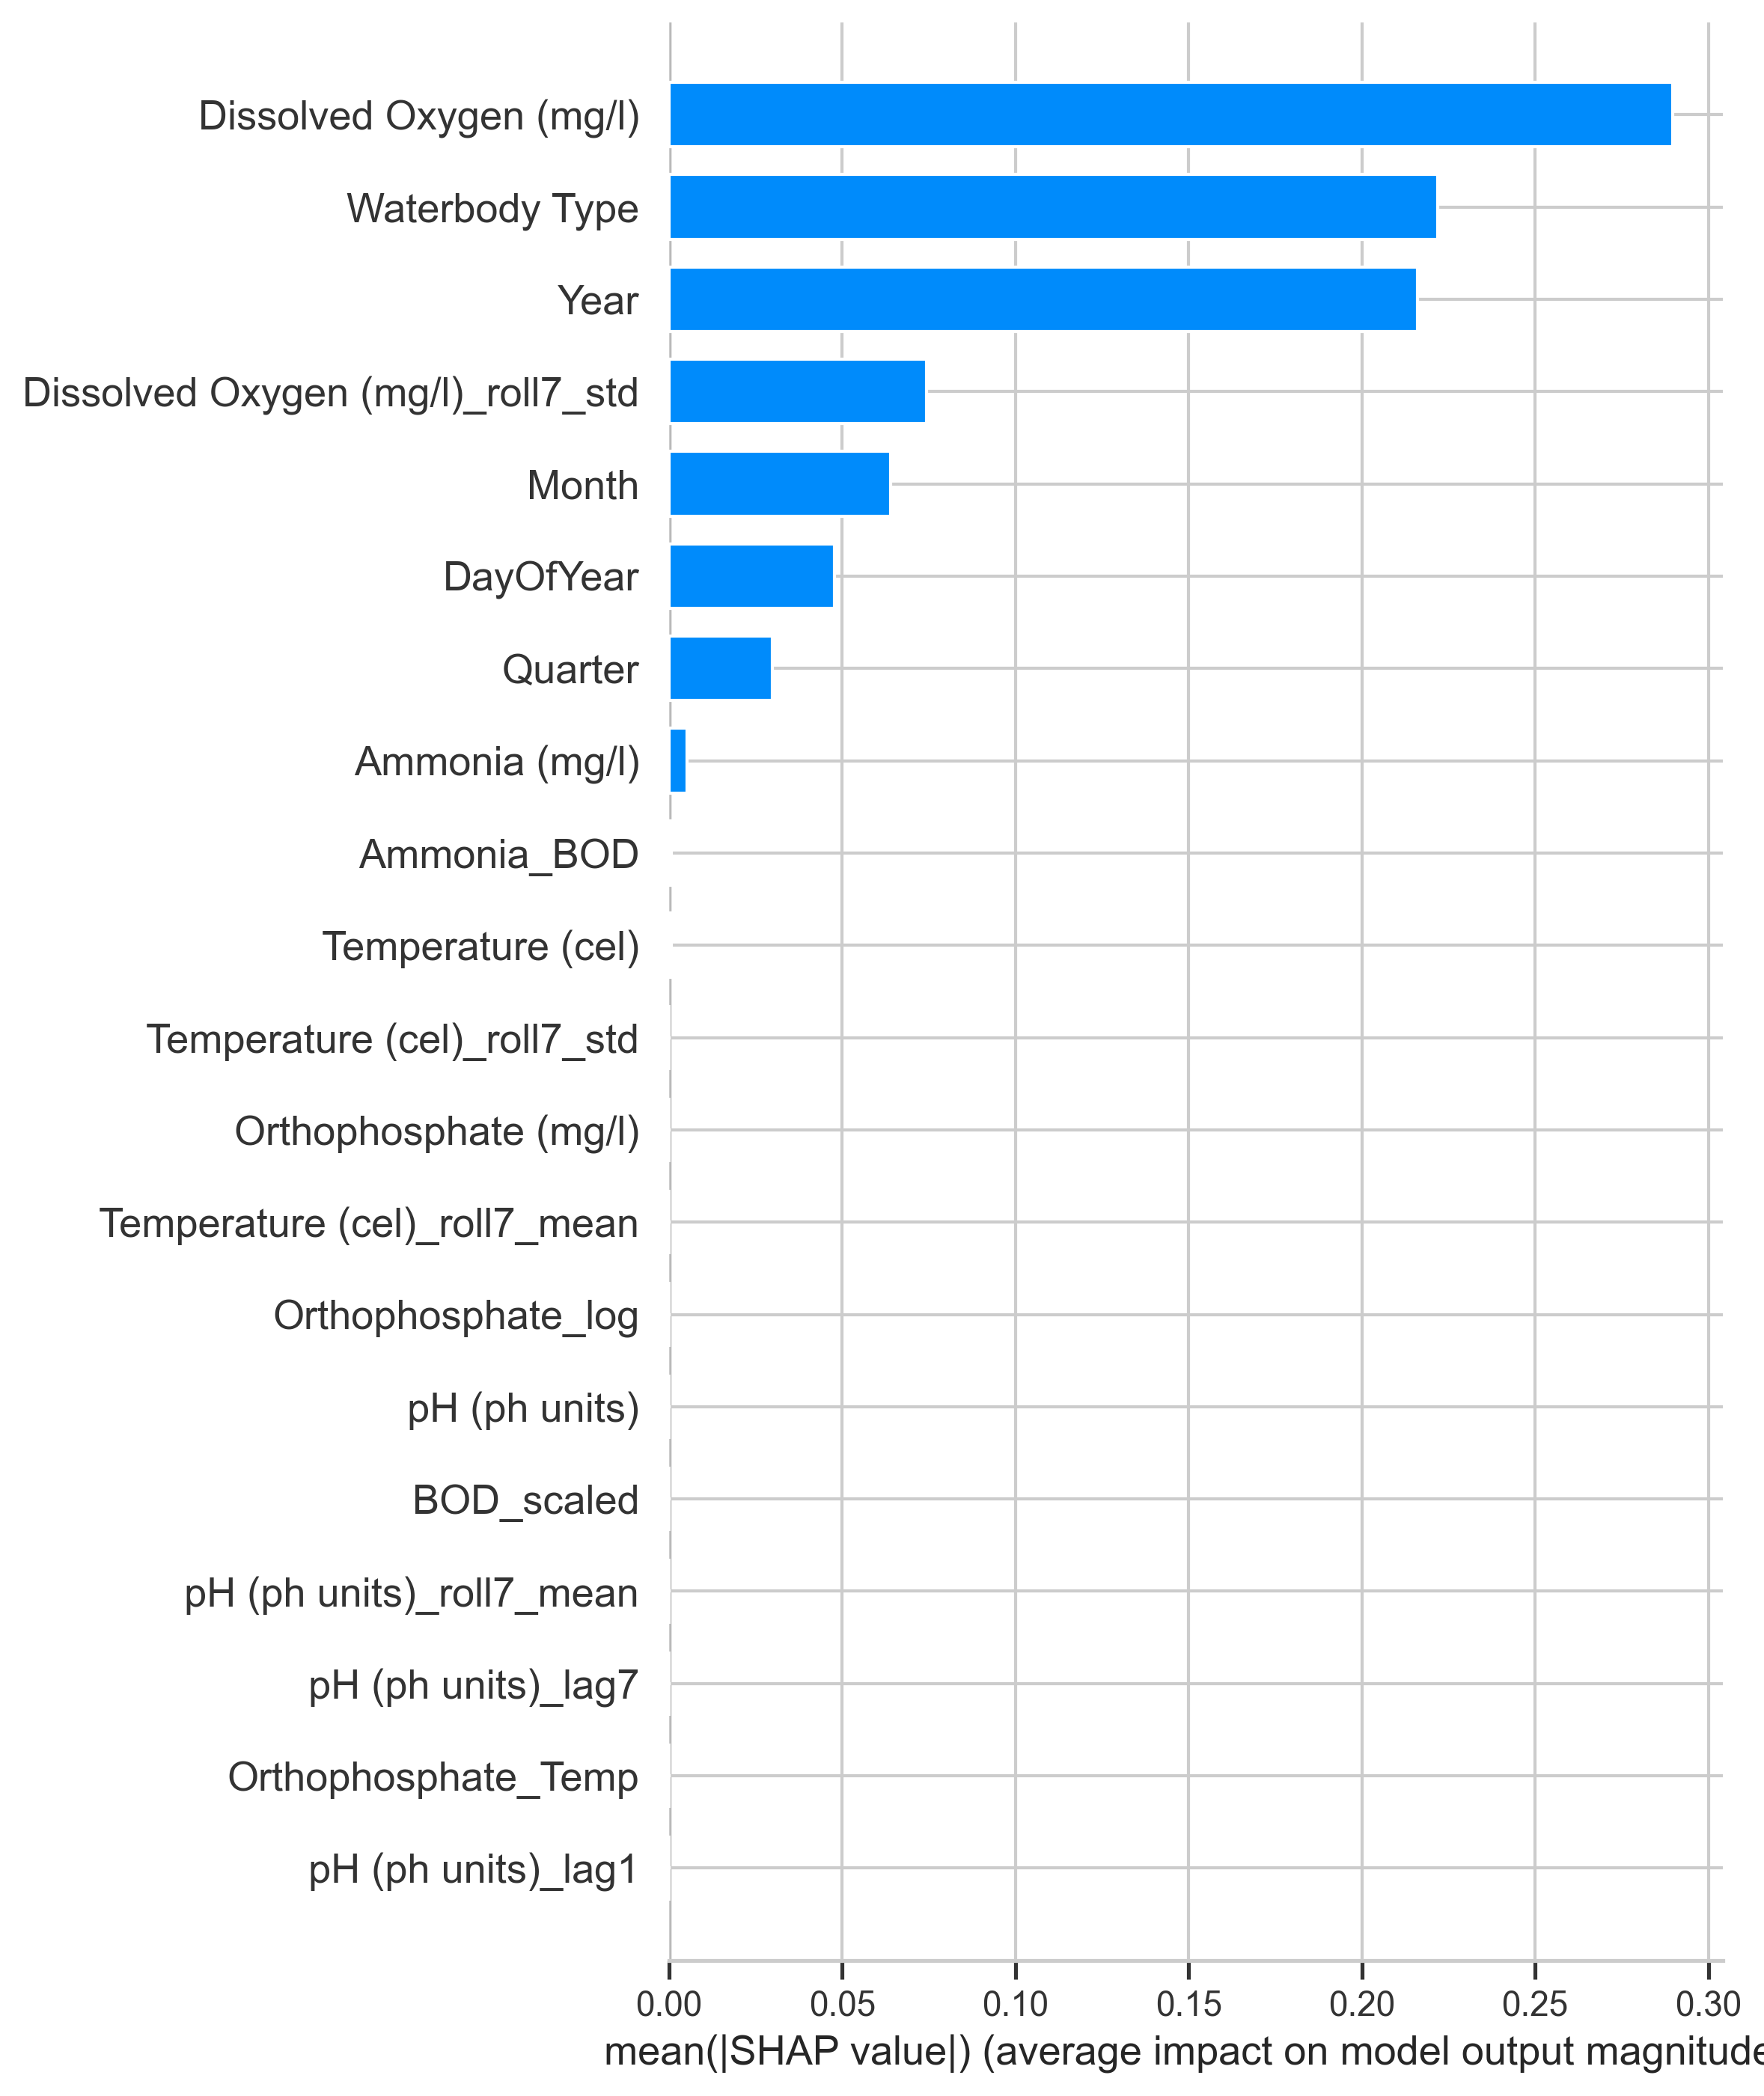

In [120]:
from IPython.display import Image, display
display(Image(filename="shap_model2_poor_class_importance.png"))

### Anomaly Detection & Predictive Maintenance (InfrastructureAnomaly)

#### Create InfrastructureAnomaly label

In [121]:
# Create InfrastructureAnomaly target
df_model['InfrastructureAnomaly'] = (
    (df_model['CCME_WQI'].isin(['Poor', 'Marginal'])) |
    (df_model.filter(like='_invalid_flag').sum(axis=1) > 0) |
    (df_model['pH_low_flag'] == 1) |
    (df_model['DO_high_flag'] == 1)
).astype(int)

# Check distribution
df_model['InfrastructureAnomaly'].value_counts(normalize=True)

InfrastructureAnomaly
0    0.855864
1    0.144136
Name: proportion, dtype: float64

#### Create anomaly targets using the SAME temporal split

In [122]:
y_train_anom = df_model.loc[X_train.index, 'InfrastructureAnomaly']
y_val_anom   = df_model.loc[X_val.index, 'InfrastructureAnomaly']
y_test_anom  = df_model.loc[X_test.index, 'InfrastructureAnomaly']

#### Train Isolation Forest (TRAIN set only)

In [123]:
from sklearn.ensemble import IsolationForest

iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.1,   # expected anomaly proportion
    random_state=42,
    n_jobs=-1
)

iso_forest.fit(X_train_processed)

,n_estimators,200
,max_samples,'auto'
,contamination,0.1
,max_features,1.0
,bootstrap,False
,n_jobs,-1
,random_state,42
,verbose,0
,warm_start,False


#### Generate anomaly scores

In [124]:
# -1 = anomaly, +1 = normal
iso_test_pred = iso_forest.predict(X_test_processed)

# Convert to binary anomaly label
iso_test_anomaly = (iso_test_pred == -1).astype(int)

# Compare with true anomalies
iso_test_anomaly.mean()

0.08618828475654793

#### Quick Sanity Check

In [125]:
pd.crosstab(
    y_test_anom,
    iso_test_anomaly,
    rownames=['True'],
    colnames=['IsolationForest']
)

IsolationForest,0,1
True,,
0,15825,575
1,259,942


#### Initialize XGBoost Classifier

In [126]:
xgb_anom = xgb.XGBClassifier(
    objective='binary:logistic',
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(len(y_train_anom) - y_train_anom.sum()) / y_train_anom.sum(),
    eval_metric='auc',
    random_state=42,
    n_jobs=-1
)

#### Train the anomaly classifier

In [127]:
xgb_anom.fit(
    X_train_processed,
    y_train_anom
)

,objective,'binary:logistic'
,use_label_encoder,None
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'auc'


#### Validation performance (focus on RECALL)

In [128]:
from sklearn.metrics import (
    roc_auc_score,
    recall_score,
    precision_score
)

y_val_pred_anom = xgb_anom.predict(X_val_processed)
y_val_prob_anom = xgb_anom.predict_proba(X_val_processed)[:, 1]

print("Validation Performance — Anomaly Model")
print("Recall   :", recall_score(y_val_anom, y_val_pred_anom))
print("Precision:", precision_score(y_val_anom, y_val_pred_anom))
print("ROC-AUC  :", roc_auc_score(y_val_anom, y_val_prob_anom))

Validation Performance — Anomaly Model
Recall   : 1.0
Precision: 1.0
ROC-AUC  : 1.0


#### Final TEST evaluation

In [129]:
y_test_pred_anom = xgb_anom.predict(X_test_processed)
y_test_prob_anom = xgb_anom.predict_proba(X_test_processed)[:, 1]

print("Test Performance — Anomaly Model")
print("Recall   :", recall_score(y_test_anom, y_test_pred_anom))
print("Precision:", precision_score(y_test_anom, y_test_pred_anom))
print("ROC-AUC  :", roc_auc_score(y_test_anom, y_test_prob_anom))

Test Performance — Anomaly Model
Recall   : 1.0
Precision: 1.0
ROC-AUC  : 1.0


#### Interpretation & reporting (Confusion Matrix)

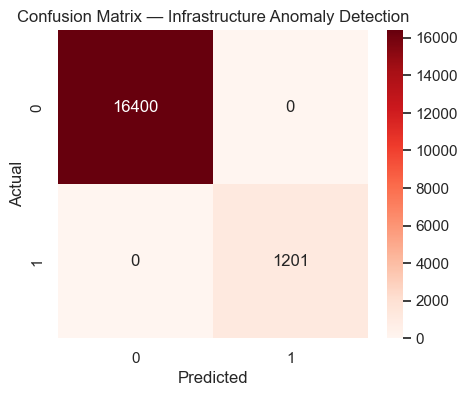

In [130]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test_anom, y_test_pred_anom)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Infrastructure Anomaly Detection")
plt.show()

#### Save Model 3: Anomaly Detection & Predictive Maintenance

In [131]:
# === Save Model 3: IsolationForest & XGBoost Anomaly Classifier ===
import joblib, os
os.makedirs("models", exist_ok=True)

# Save Isolation Forest unsupervised detector (variable: iso_forest)
if 'iso_forest' in globals():
    joblib.dump(iso_forest, "models/isolation_forest.joblib", compress=3)
    print("Saved IsolationForest to models/isolation_forest.joblib")
else:
    print("iso_forest not found in globals(); skip.")

# Save supervised anomaly classifier (variable: xgb_anom)
if 'xgb_anom' in globals():
    joblib.dump(xgb_anom, "models/xgb_anomaly.joblib", compress=3)
    print("Saved supervised anomaly classifier to models/xgb_anomaly.joblib")
else:
    print("xgb_anom not found in globals(); skip.")

Saved IsolationForest to models/isolation_forest.joblib
Saved supervised anomaly classifier to models/xgb_anomaly.joblib


### SHAP Explainability for Anomaly Detection & Predictive Maintenance

#### Create SHAP TreeExplainer

In [132]:
import shap
import matplotlib.pyplot as plt

explainer_anom = shap.TreeExplainer(xgb_anom)

#### Compute SHAP values (TEST set only)

In [133]:
shap_values_anom = explainer_anom.shap_values(X_test_processed)

print("SHAP shape:", shap_values_anom.shape)
print("X_test shape:", X_test_processed.shape)

SHAP shape: (17601, 100)
X_test shape: (17601, 100)


#### Global Feature Importance

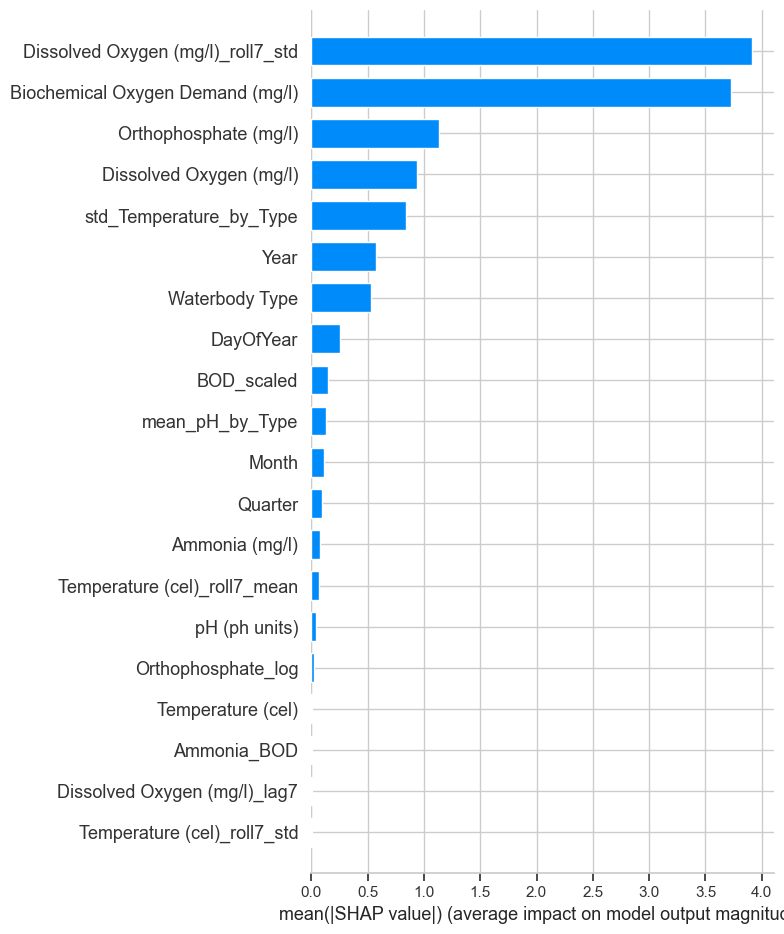

In [134]:
shap.summary_plot(
    shap_values_anom,
    X_test_processed,
    feature_names=feature_cols,
    plot_type="bar",
    show=True
)

#### Detailed Impact Distribution (Beeswarm Plot)

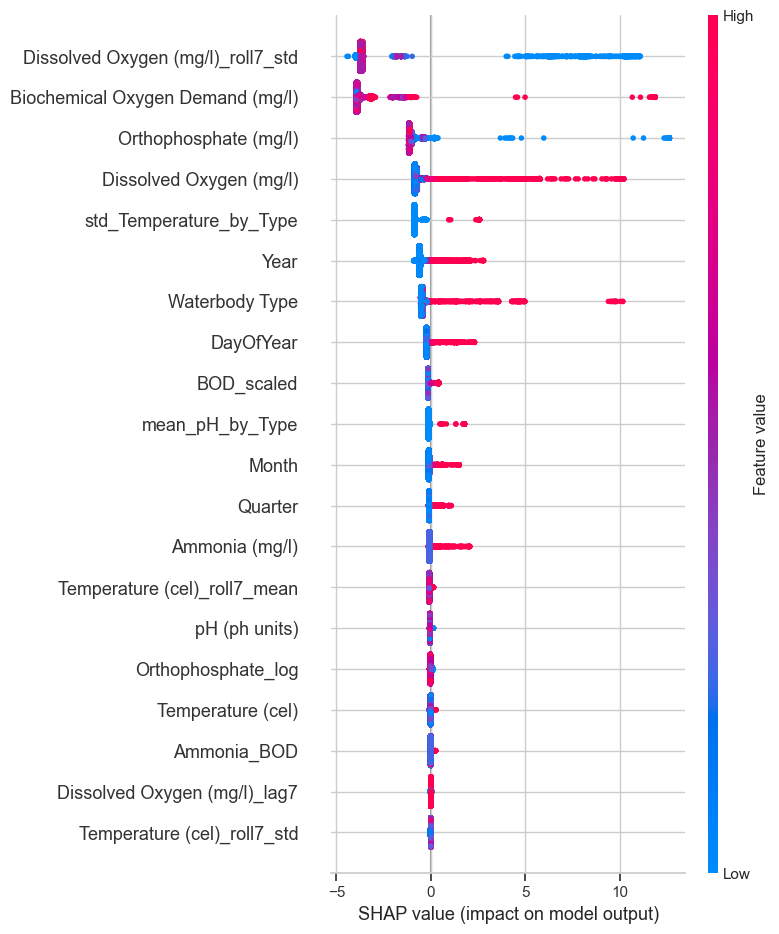

In [135]:
shap.summary_plot(
    shap_values_anom,
    X_test_processed,
    feature_names=feature_cols,
    show=True
)

#### Explain a single anomaly (Force Plot)

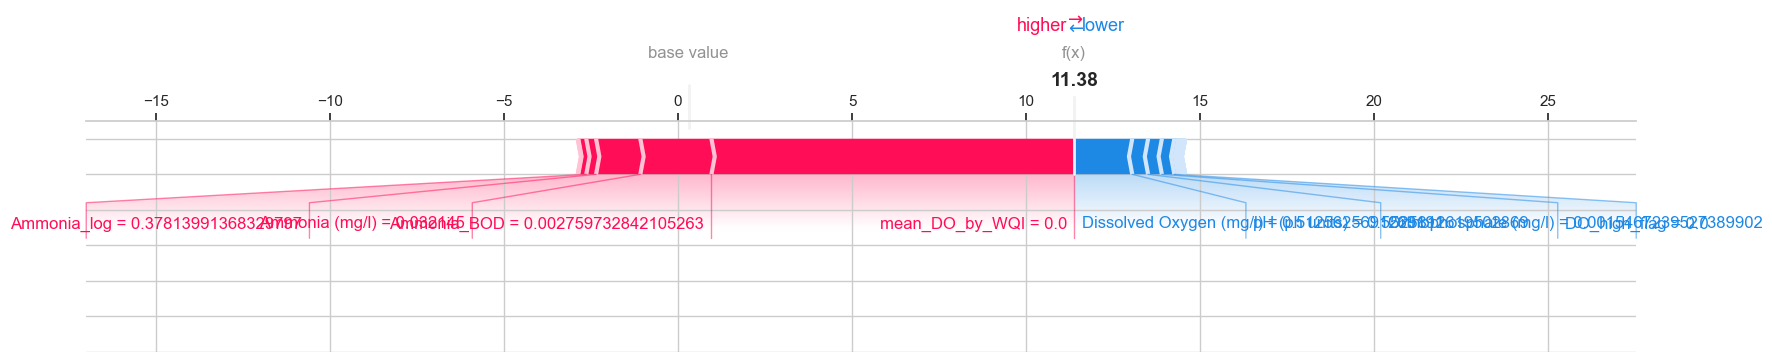

In [136]:
feature_cols = X_test_processed.columns.tolist()

# Pick first anomaly by label
anom_positions = y_test_anom[y_test_anom == 1].index

# Convert label index to integer positional index
pos = X_test_processed.index.get_loc(anom_positions[0])

shap.force_plot(
    float(explainer_anom.expected_value),
    shap_values_anom[pos],
    X_test_processed.iloc[pos],
    feature_names=feature_cols,
    matplotlib=True
)

#### Save SHAP figures for dissertation

In [137]:
plt.figure()
shap.summary_plot(
    shap_values_anom,
    X_test_processed,
    feature_names=feature_cols,
    plot_type="bar",
    show=False
)
plt.savefig("shap_model3_anomaly_feature_importance.png", dpi=300, bbox_inches="tight")
plt.close()

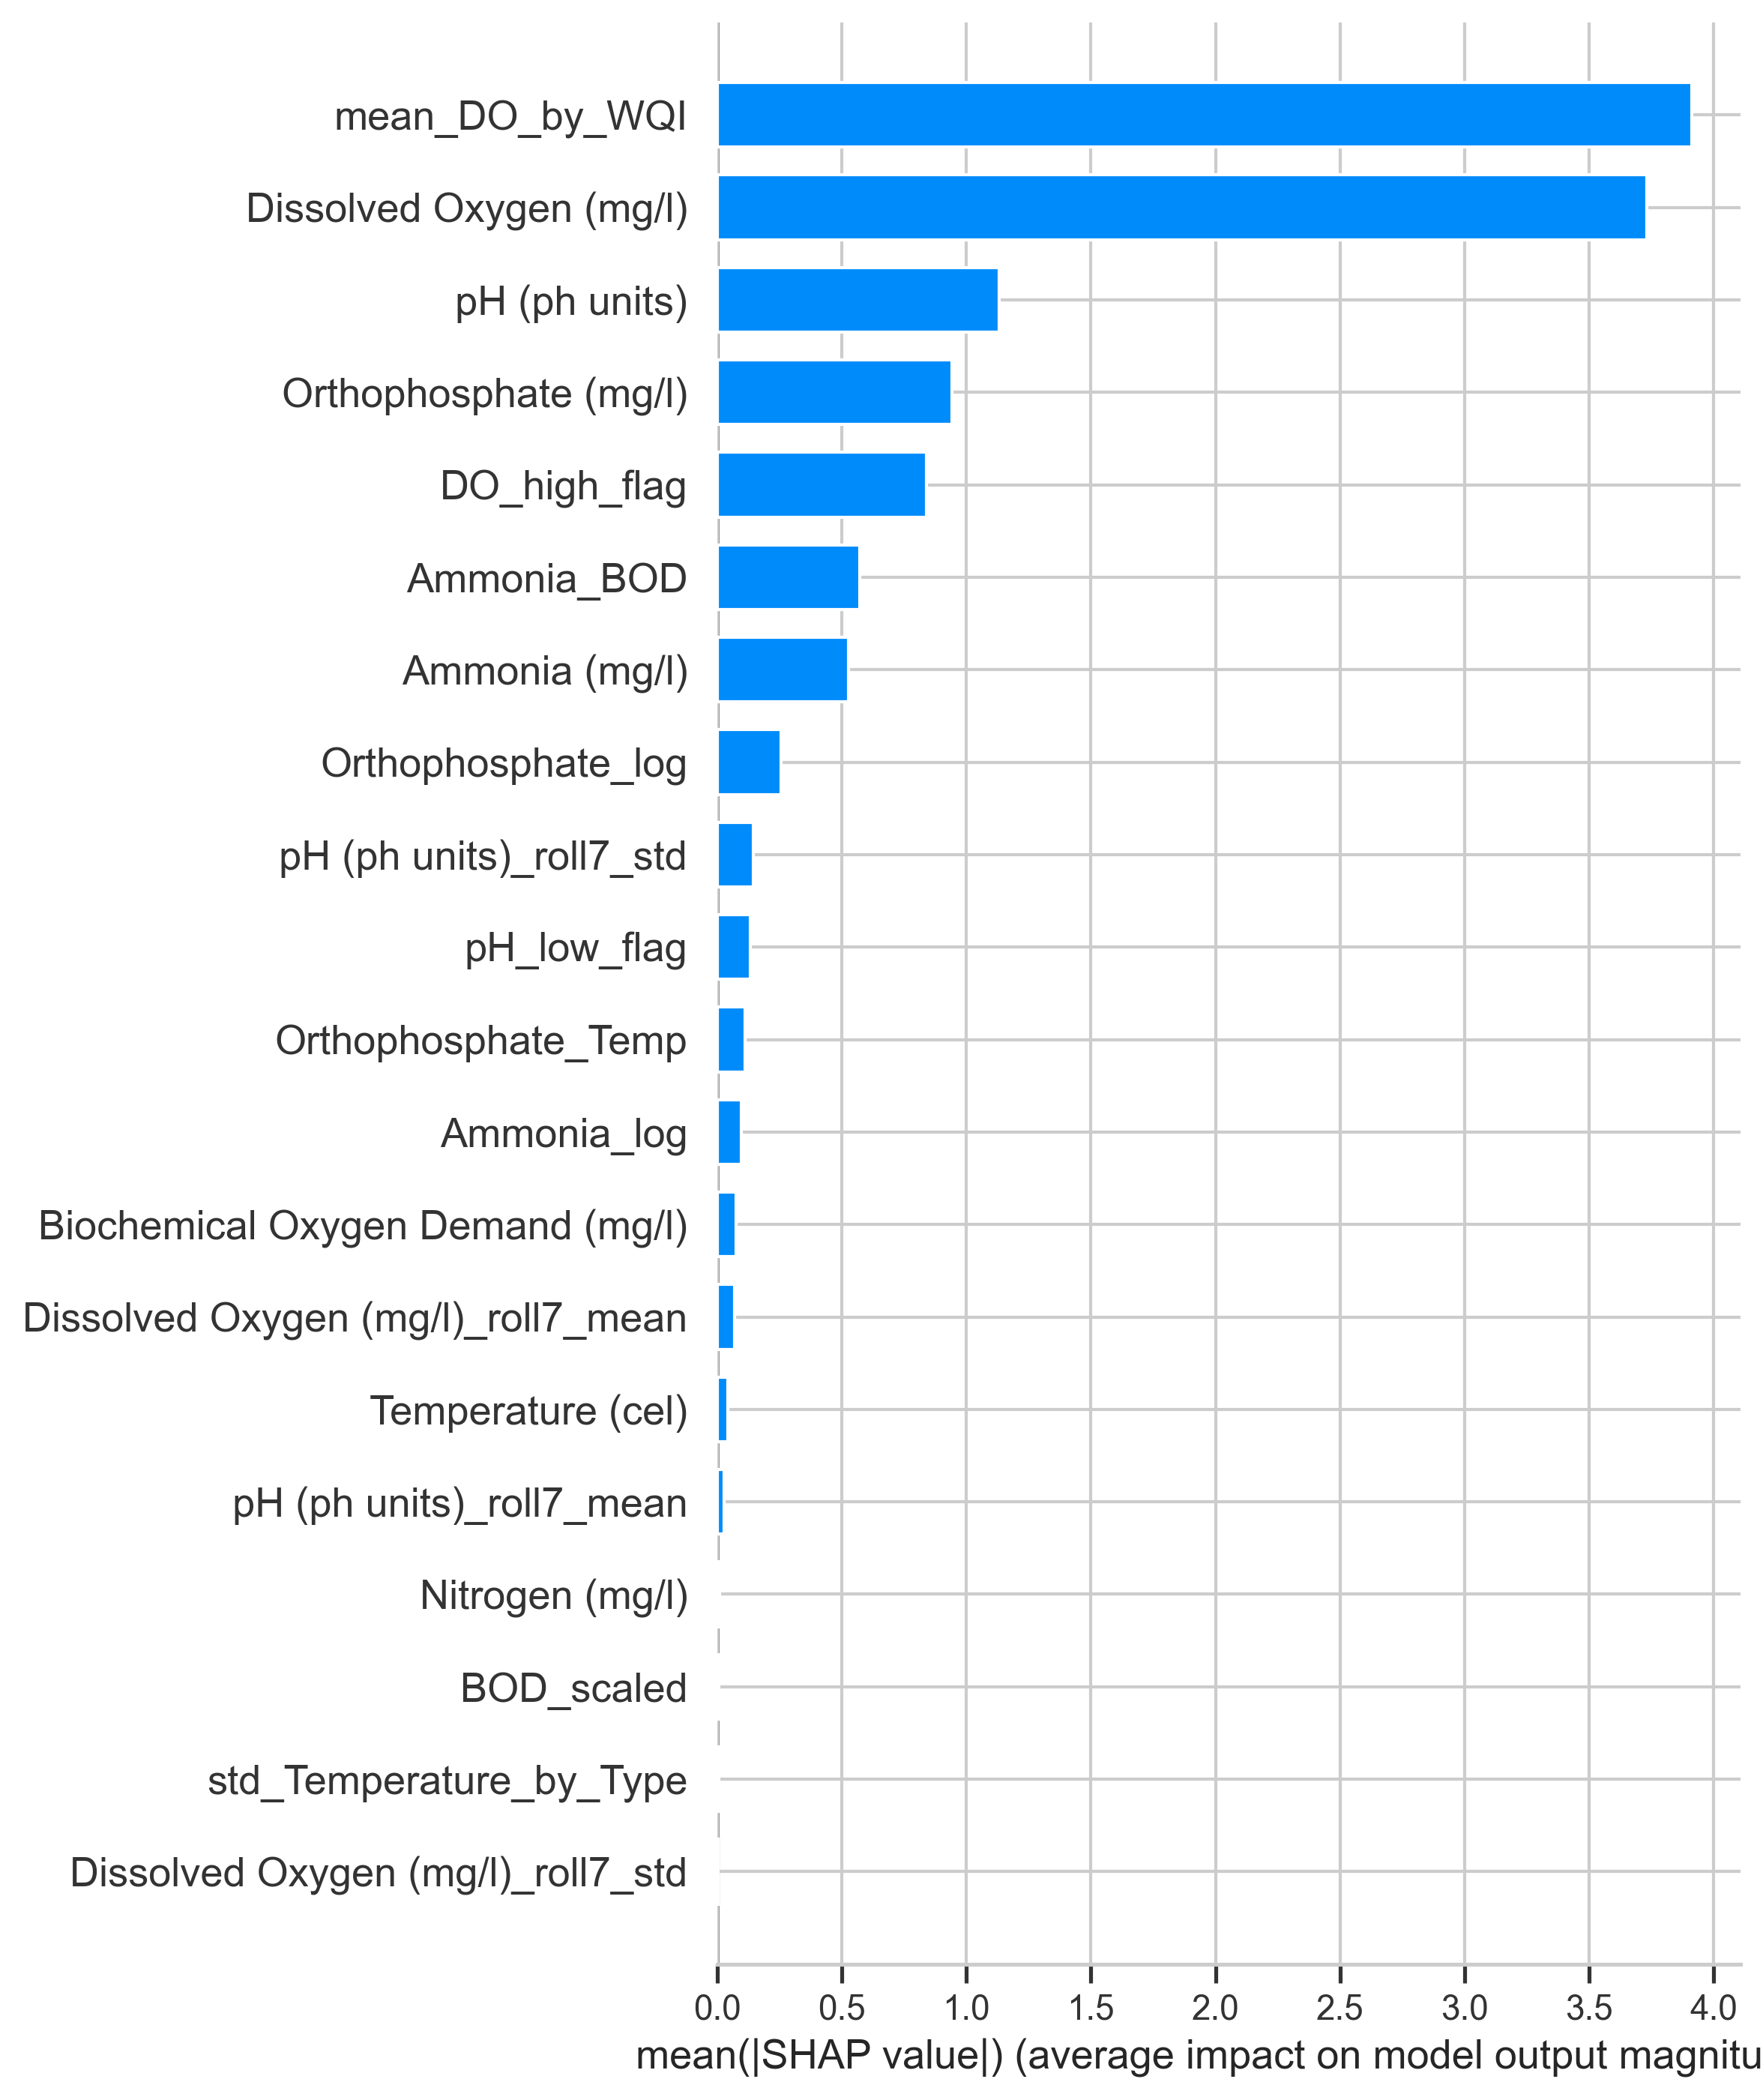

In [138]:
from IPython.display import Image, display
display(Image(filename="shap_model3_anomaly_feature_importance.png"))

### FEATURE-AWARE NEURAL ARCHITECTURE

#### Define feature groups

In [139]:
# Time-based features
time_features = [
    'Year', 'Month', 'Quarter', 'DayOfYear', 'Season'
]

# Physicochemical measurements
phys_features = [
    'Ammonia (mg/l)',
    'Biochemical Oxygen Demand (mg/l)',
    'Dissolved Oxygen (mg/l)',
    'Orthophosphate (mg/l)',
    'pH (ph units)',
    'Temperature (cel)',
    'Nitrogen (mg/l)',
    'Nitrate (mg/l)'
]

# Interaction & transformed features
interaction_features = [
    'Ammonia_BOD',
    'Orthophosphate_Temp',
    'Ammonia_log',
    'Orthophosphate_log',
    'BOD_scaled'
]

# Statistical & lag-based features
stat_features = [
    col for col in feature_cols
    if ('lag' in col or 'roll' in col or 'mean_' in col or 'std_' in col)
]

# Binary flags & encodings
flag_features = [
    col for col in feature_cols
    if col not in (
        time_features + phys_features + interaction_features + stat_features
    )
]

#### Sanity check

In [140]:
print("Time features:", len(time_features))
print("Physicochemical:", len(phys_features))
print("Interaction:", len(interaction_features))
print("Statistical:", len(stat_features))
print("Flags:", len(flag_features))
print("Total:", sum([
    len(time_features),
    len(phys_features),
    len(interaction_features),
    len(stat_features),
    len(flag_features)
]))

Time features: 5
Physicochemical: 8
Interaction: 5
Statistical: 85
Flags: 1
Total: 104


#### Create branch-wise input matrices

In [141]:
# Rebuild feature names from processed data
feature_cols = X_train_processed.columns.tolist()

# Filter feature groups to only existing columns
time_features = [c for c in time_features if c in feature_cols]
phys_features = [c for c in phys_features if c in feature_cols]
interaction_features = [c for c in interaction_features if c in feature_cols]
stat_features = [c for c in stat_features if c in feature_cols]
flag_features = [c for c in flag_features if c in feature_cols]

# Training
X_train_time = X_train_processed[time_features]
X_train_phys = X_train_processed[phys_features]
X_train_inter = X_train_processed[interaction_features]
X_train_stat = X_train_processed[stat_features]
X_train_flag = X_train_processed[flag_features]

# Validation
X_val_time = X_val_processed[time_features]
X_val_phys = X_val_processed[phys_features]
X_val_inter = X_val_processed[interaction_features]
X_val_stat = X_val_processed[stat_features]
X_val_flag = X_val_processed[flag_features]

# Test
X_test_time = X_test_processed[time_features]
X_test_phys = X_test_processed[phys_features]
X_test_inter = X_test_processed[interaction_features]
X_test_stat = X_test_processed[stat_features]
X_test_flag = X_test_processed[flag_features]

In [142]:
print(X_train_processed.shape[1])
print(
    X_train_time.shape[1]
    + X_train_phys.shape[1]
    + X_train_inter.shape[1]
    + X_train_stat.shape[1]
    + X_train_flag.shape[1]
)

100
100


In [143]:
X_train_time  = X_train_time.to_numpy(dtype="float32")
X_train_phys  = X_train_phys.to_numpy(dtype="float32")
X_train_inter = X_train_inter.to_numpy(dtype="float32")
X_train_stat  = X_train_stat.to_numpy(dtype="float32")
X_train_flag  = X_train_flag.to_numpy(dtype="float32")

y_train_reg = y_train_reg.to_numpy(dtype="float32")

In [144]:
X_val_time  = X_val_time.to_numpy(dtype="float32")
X_val_phys  = X_val_phys.to_numpy(dtype="float32")
X_val_inter = X_val_inter.to_numpy(dtype="float32")
X_val_stat  = X_val_stat.to_numpy(dtype="float32")
X_val_flag  = X_val_flag.to_numpy(dtype="float32")

y_val_reg = y_val_reg.to_numpy(dtype="float32")

In [145]:
X_test_time  = X_test_time.to_numpy(dtype="float32")
X_test_phys  = X_test_phys.to_numpy(dtype="float32")
X_test_inter = X_test_inter.to_numpy(dtype="float32")
X_test_stat  = X_test_stat.to_numpy(dtype="float32")
X_test_flag  = X_test_flag.to_numpy(dtype="float32")

y_test_reg = y_test_reg.to_numpy(dtype="float32")

#### Build the Feature-Aware Neural Network

#### Import Necessarry Libraries

In [146]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Dropout, Concatenate
from tensorflow.keras.models import Model

#### Define each feature branch

In [147]:
# Time branch
input_time = Input(shape=(X_train_time.shape[1],), name='time_input')
x_time = Dense(32, activation='relu')(input_time)
x_time = Dropout(0.2)(x_time)

# Physicochemical branch
input_phys = Input(shape=(X_train_phys.shape[1],), name='phys_input')
x_phys = Dense(64, activation='relu')(input_phys)
x_phys = Dense(32, activation='relu')(x_phys)

# Interaction branch
input_inter = Input(shape=(X_train_inter.shape[1],), name='inter_input')
x_inter = Dense(32, activation='relu')(input_inter)

# Statistical branch
input_stat = Input(shape=(X_train_stat.shape[1],), name='stat_input')
x_stat = Dense(64, activation='relu')(input_stat)
x_stat = Dense(32, activation='relu')(x_stat)

# Flag branch
input_flag = Input(shape=(X_train_flag.shape[1],), name='flag_input')
x_flag = Dense(16, activation='relu')(input_flag)

2026-01-06 10:13:31.959656: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2026-01-06 10:13:31.959719: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-01-06 10:13:31.959728: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-01-06 10:13:31.959946: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-01-06 10:13:31.959966: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


#### Feature fusion & shared representation

In [148]:
# Fuse all branches
fusion = Concatenate()([
    x_time, x_phys, x_inter, x_stat, x_flag
])

fusion = Dense(64, activation='relu')(fusion)
fusion = Dropout(0.3)(fusion)

#### Output heads (Minimum required: Regression CCME_Values)

In [149]:
# Regression head (mandatory)
output_reg = Dense(1, activation='linear', name='ccme_regression')(fusion)

#### Build model

In [150]:
feature_aware_model = Model(
    inputs=[
        input_time,
        input_phys,
        input_inter,
        input_stat,
        input_flag
    ],
    outputs=output_reg
)

#### Compile the model

In [151]:
feature_aware_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

feature_aware_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ time_input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ phys_input          │ (None, 8)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stat_input          │ (None, 85)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │         64 │ time_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │        576 │ phys_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inter_input         │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │      5,504 │ stat_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flag_input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 32)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      2,080 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 32)        │        192 │ inter_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 32)        │      2,080 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 16)        │         32 │ flag_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 144)       │          0 │ dropout[0][0],    │
│ (Concatenate)       │                   │            │ dense_2[0][0],    │
│                     │                   │            │ dense_3[0][0],    │
│                     │                   │            │ dense_5[0][0],    │
│                     │                   │            │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 64)        │      9,280 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ccme_regression     │ (None, 1)         │         65 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 19,873 (77.63 KB)

 Trainable params: 19,873 (77.63 KB)

 Non-trainable params: 0 (0.00 B)

#### Train the model (with early stopping)

In [152]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = feature_aware_model.fit(
    [
        X_train_time, X_train_phys, X_train_inter,
        X_train_stat, X_train_flag
    ],
    y_train_reg,
    validation_data=(
        [
            X_val_time, X_val_phys, X_val_inter,
            X_val_stat, X_val_flag
        ],
        y_val_reg
    ),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30


2026-01-06 10:14:05.562418: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


6158/6158 ━━━━━━━━━━━━━━━━━━━━ 125s 20ms/step - loss: 138.9303 - mae: 7.6891 - val_loss: 7.9274 - val_mae: 2.1219
Epoch 2/30
6158/6158 ━━━━━━━━━━━━━━━━━━━━ 120s 19ms/step - loss: 65.4182 - mae: 6.3399 - val_loss: 6.6313 - val_mae: 1.9633
Epoch 3/30
6158/6158 ━━━━━━━━━━━━━━━━━━━━ 122s 20ms/step - loss: 67.3669 - mae: 6.3773 - val_loss: 6.8305 - val_mae: 2.0343
Epoch 4/30
6158/6158 ━━━━━━━━━━━━━━━━━━━━ 122s 20ms/step - loss: 76.7995 - mae: 6.6156 - val_loss: 8.2627 - val_mae: 1.8028
Epoch 5/30
6158/6158 ━━━━━━━━━━━━━━━━━━━━ 121s 20ms/step - loss: 82.3843 - mae: 6.7861 - val_loss: 11.9379 - val_mae: 2.3969
Epoch 6/30
6158/6158 ━━━━━━━━━━━━━━━━━━━━ 121s 20ms/step - loss: 96.3323 - mae: 7.0643 - val_loss: 9.8291 - val_mae: 2.3470
Epoch 7/30
6158/6158 ━━━━━━━━━━━━━━━━━━━━ 121s 20ms/step - loss: 107.8439 - mae: 7.2711 - val_loss: 203.8356 - val_mae: 12.1816


#### Final evaluation on TEST set

In [153]:
test_loss, test_mae = feature_aware_model.evaluate(
    [
        X_test_time,
        X_test_phys,
        X_test_inter,
        X_test_stat,
        X_test_flag
    ],
    y_test_reg,
    verbose=0
)

print("Feature-Aware NN Test MAE:", test_mae)

Feature-Aware NN Test MAE: 1.9804372787475586


#### Regression target

In [154]:
y_train_reg
y_val_reg
y_test_reg

array([89.633934, 89.633934, 89.633934, ..., 91.87448 , 92.451515,
       93.19558 ], dtype=float32)

#### Classification target (encoded)

In [155]:
y_train_cls
y_val_cls
y_test_cls

num_classes = len(wqi_encoder.classes_)

#### Anomaly target

In [156]:
y_train_anom
y_val_anom
y_test_anom

223172    0
223173    0
223174    0
223175    0
223176    0
         ..
240768    0
240769    0
240770    0
240771    0
240772    1
Name: InfrastructureAnomaly, Length: 17601, dtype: int64

#### Define the three output heads

In [157]:
from tensorflow.keras.layers import Dense

In [158]:
# --- Regression head (CCME Values) ---
output_reg = Dense(
    1,
    activation='linear',
    name='ccme_regression'
)(fusion)

# --- Classification head (CCME WQI) ---
output_cls = Dense(
    num_classes,
    activation='softmax',
    name='ccme_classification'
)(fusion)

# --- Anomaly detection head ---
output_anom = Dense(
    1,
    activation='sigmoid',
    name='infrastructure_anomaly'
)(fusion)

#### Build the multi-task model

In [159]:
multi_task_model = Model(
    inputs=[
        input_time,
        input_phys,
        input_inter,
        input_stat,
        input_flag
    ],
    outputs=[
        output_reg,
        output_cls,
        output_anom
    ]
)

#### Compile the multi-task model

In [160]:
losses = {
    'ccme_regression': 'mse',
    'ccme_classification': 'sparse_categorical_crossentropy',
    'infrastructure_anomaly': 'binary_crossentropy'
}

#### Loss weights

In [161]:
loss_weights = {
    'ccme_regression': 1.0,
    'ccme_classification': 0.6,
    'infrastructure_anomaly': 0.8
}

#### Compile

In [162]:
multi_task_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=losses,
    loss_weights=loss_weights,
    metrics={
        'ccme_regression': ['mae'],
        'ccme_classification': ['accuracy'],
        'infrastructure_anomaly': ['Recall']
    }
)

multi_task_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ time_input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ phys_input          │ (None, 8)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stat_input          │ (None, 85)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │         64 │ time_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │        576 │ phys_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inter_input         │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │      5,504 │ stat_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flag_input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 32)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      2,080 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 32)        │        192 │ inter_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 32)        │      2,080 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 16)        │         32 │ flag_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 144)       │          0 │ dropout[0][0],    │
│ (Concatenate)       │                   │            │ dense_2[0][0],    │
│                     │                   │            │ dense_3[0][0],    │
│                     │                   │            │ dense_5[0][0],    │
│                     │                   │            │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 64)        │      9,280 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ccme_regression     │ (None, 1)         │         65 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ccme_classification │ (None, 5)         │        325 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ infrastructure_ano… │ (None, 1)         │         65 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                 

 Total params: 20,263 (79.15 KB)

 Trainable params: 20,263 (79.15 KB)

 Non-trainable params: 0 (0.00 B)

#### Train the multi-task model (Early stopping)

In [164]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

#### Model training

In [165]:
history = multi_task_model.fit(
    [
        X_train_time, X_train_phys, X_train_inter,
        X_train_stat, X_train_flag
    ],
    {
        'ccme_regression': y_train_reg,
        'ccme_classification': y_train_cls,
        'infrastructure_anomaly': y_train_anom
    },
    validation_data=(
        [
            X_val_time, X_val_phys, X_val_inter,
            X_val_stat, X_val_flag
        ],
        {
            'ccme_regression': y_val_reg,
            'ccme_classification': y_val_cls,
            'infrastructure_anomaly': y_val_anom
        }
    ),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
6158/6158 ━━━━━━━━━━━━━━━━━━━━ 181s 29ms/step - ccme_classification_accuracy: 0.6944 - ccme_classification_loss: 2.0080 - ccme_regression_loss: 182.6175 - ccme_regression_mae: 8.4926 - infrastructure_anomaly_Recall: 0.2857 - infrastructure_anomaly_loss: 0.6360 - loss: 184.3428 - val_ccme_classification_accuracy: 0.7626 - val_ccme_classification_loss: 0.6856 - val_ccme_regression_loss: 6.2748 - val_ccme_regression_mae: 1.7166 - val_infrastructure_anomaly_Recall: 0.1414 - val_infrastructure_anomaly_loss: 0.4489 - val_loss: 7.0304
Epoch 2/30
6158/6158 ━━━━━━━━━━━━━━━━━━━━ 178s 29ms/step - ccme_classification_accuracy: 0.7102 - ccme_classification_loss: 0.8513 - ccme_regression_loss: 76.8701 - ccme_regression_mae: 6.7538 - infrastructure_anomaly_Recall: 0.2742 - infrastructure_anomaly_loss: 0.3823 - loss: 77.6868 - val_ccme_classification_accuracy: 0.7237 - val_ccme_classification_loss: 0.6422 - val_ccme_regression_loss: 7.7572 - val_ccme_regression_mae: 1.7549 - val_infrastruct

#### Evaluate on TEST set

In [166]:
results = multi_task_model.evaluate(
    [
        X_test_time,
        X_test_phys,
        X_test_inter,
        X_test_stat,
        X_test_flag
    ],
    {
        'ccme_regression': y_test_reg,
        'ccme_classification': y_test_cls,
        'infrastructure_anomaly': y_test_anom
    },
    verbose=0
)

for name, value in zip(multi_task_model.metrics_names, results):
    print(f"{name}: {value:.4f}")

loss: 7.0235
compile_metrics: 6.4842
ccme_regression_loss: 0.6222
ccme_classification_loss: 0.1960
infrastructure_anomaly_loss: 0.7143


#### Save Model 4: Feature-Aware Neural Architecture

In [167]:
# === Save Model 4: Multi-task Neural Model (Keras) ===
import os
os.makedirs("models", exist_ok=True)

# multi_task_model is the trained Keras model variable
if 'multi_task_model' in globals():
    # Save in native Keras format
    multi_task_model.save("models/multi_task_model.keras")
    print("Saved multi-task model to models/multi_task_model.keras")
else:
    print("multi_task_model not found in globals(); skip saving.")

Saved multi-task model to models/multi_task_model.keras


#### Save other Artifacts

In [169]:
# === Save metadata artifacts (re-save / ensure consistency) ===
import joblib, json, os
os.makedirs("models", exist_ok=True)

# feature_cols already exists as variable `feature_cols` in many places
if 'feature_cols' in globals():
    with open("models/feature_columns.json", "w") as f:
        json.dump(feature_cols, f)
    print("Saved models/feature_columns.json")
else:
    print("feature_cols variable not found; skip.")

# feature_groups & feature_group_indices
if 'feature_groups' in globals():
    joblib.dump(feature_groups, "models/feature_groups.joblib", compress=3)
    print("Saved models/feature_groups.joblib")

if 'feature_group_indices' in globals():
    joblib.dump(feature_group_indices, "models/feature_group_indices.joblib", compress=3)
    print("Saved models/feature_group_indices.joblib")

Saved models/feature_columns.json


#### Verify that all the files are saved

In [170]:
# === Verify saved artifacts ===
import os, glob, pprint

files = sorted(glob.glob("models/*"))
print("Saved model files in ./models/:")
pprint.pprint(files)

Saved model files in ./models/:
['models/feature_columns.json',
 'models/feature_group_indices.joblib',
 'models/feature_groups.joblib',
 'models/isolation_forest.joblib',
 'models/multi_task_model.keras',
 'models/preprocessor.joblib',
 'models/wqi_label_encoder.joblib',
 'models/xgb_anomaly.joblib',
 'models/xgb_classification.joblib',
 'models/xgb_regression.joblib']


### Explainability-SHAP & Integrated Gradients for Feature-Aware Neural Architecture

#### Define Integrated Gradients function

In [171]:
import tensorflow as tf
import numpy as np

def integrated_gradients(
    model,
    inputs,
    baseline,
    target_fn,
    steps=50
):
    """
    Correct Integrated Gradients for multi-input Keras models
    Compatible with TF 2.10–2.20
    """

    # Ensure tensors
    inputs = [tf.cast(x, tf.float32) for x in inputs]
    baseline = [tf.cast(b, tf.float32) for b in baseline]

    # Initialize accumulator
    accumulated_grads = [tf.zeros_like(x) for x in inputs]

    for alpha in tf.linspace(0.0, 1.0, steps):
        interpolated = [
            baseline[i] + alpha * (inputs[i] - baseline[i])
            for i in range(len(inputs))
        ]

        with tf.GradientTape() as tape:
            tape.watch(interpolated)
            preds = model(interpolated, training=False)
            target = target_fn(preds)

        grads = tape.gradient(target, interpolated)

        accumulated_grads = [
            acc + g for acc, g in zip(accumulated_grads, grads)
        ]

    # Average gradients
    avg_grads = [g / steps for g in accumulated_grads]

    # Integrated gradients
    ig = [
        (inputs[i] - baseline[i]) * avg_grads[i]
        for i in range(len(inputs))
    ]

    return ig

#### Regression Head

In [172]:
def regression_target(preds):
    return preds[0][:, 0]  # assuming first output is regression

#### Classification Head

In [173]:
poor_index = list(wqi_encoder.classes_).index("Poor")

def classification_target(preds):
    return preds[1][:, poor_index]

#### Anomaly Head

In [174]:
def anomaly_target(preds):
    return preds[2][:, 0]

#### Prepare sample

In [175]:
sample_inputs = [
    tf.convert_to_tensor(X_test_time[:1], dtype=tf.float32),
    tf.convert_to_tensor(X_test_phys[:1], dtype=tf.float32),
    tf.convert_to_tensor(X_test_inter[:1], dtype=tf.float32),
    tf.convert_to_tensor(X_test_stat[:1], dtype=tf.float32),
    tf.convert_to_tensor(X_test_flag[:1], dtype=tf.float32)
]

#### Prepare baseline

In [176]:
baseline_inputs = [
    tf.zeros_like(sample_inputs[0]),
    tf.zeros_like(sample_inputs[1]),
    tf.zeros_like(sample_inputs[2]),
    tf.zeros_like(sample_inputs[3]),
    tf.zeros_like(sample_inputs[4])
]

#### Compute Integrated Gradients for Regression

In [177]:
ig_reg = integrated_gradients(
    model=multi_task_model,
    inputs=sample_inputs,
    baseline=baseline_inputs,
    target_fn=regression_target,
    steps=50
)

#### Compute Integrated Gradients for Classification

In [178]:
ig_cls = integrated_gradients(
    model=multi_task_model,
    inputs=sample_inputs,
    baseline=baseline_inputs,
    target_fn=classification_target,
    steps=50
)

#### Compute Integrated Gradients for Anomaly

In [179]:
ig_anom = integrated_gradients(
    model=multi_task_model,
    inputs=sample_inputs,
    baseline=baseline_inputs,
    target_fn=anomaly_target,
    steps=50
)

#### Aggregate by feature group

In [180]:
group_names = [
    "Temporal",
    "Physicochemical",
    "Interaction",
    "Statistical",
    "Flags"
]

def summarize_ig(ig_list):
    return {
        name: float(tf.reduce_mean(tf.abs(ig)).numpy())
        for name, ig in zip(group_names, ig_list)
    }

In [181]:
summary_reg  = summarize_ig(ig_reg)
summary_cls  = summarize_ig(ig_cls)
summary_anom = summarize_ig(ig_anom)

summary_reg, summary_cls, summary_anom

({'Temporal': 2.150177001953125,
  'Physicochemical': 0.8786773681640625,
  'Interaction': 0.9869615435600281,
  'Statistical': 0.06562639027833939,
  'Flags': 0.040925171226263046},
 {'Temporal': 1.1584501529331047e-30,
  'Physicochemical': 5.145895791911082e-31,
  'Interaction': 5.381545263629465e-31,
  'Statistical': 4.06163949224298e-32,
  'Flags': 4.453467318076161e-32},
 {'Temporal': 0.001277312752790749,
  'Physicochemical': 0.0041535478085279465,
  'Interaction': 0.0027676993049681187,
  'Statistical': 2.0428820789675228e-05,
  'Flags': 2.7718315322999842e-05})

#### Visualization

In [249]:
COLORS = {
    "reg": "#4DB6AC",   # blue-ish
    "cls": "#81C784",   # green
    "anom": "#673AB7"   # orange
}

In [250]:
def plot_ig(summary, title, bar_color):
    fig, ax = plt.subplots(figsize=(8, 4))
    fig.patch.set_facecolor("black")
    ax.set_facecolor("black")

    ax.bar(
        summary.keys(),
        summary.values(),
        color=bar_color,
        edgecolor="white",
        linewidth=0.8
    )

    ax.set_ylabel("Mean |Integrated Gradient|", color="white")
    ax.set_title(title, color="white")
    ax.tick_params(axis="x", colors="white")
    ax.tick_params(axis="y", colors="white")

    for spine in ax.spines.values():
        spine.set_color("white")

    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()

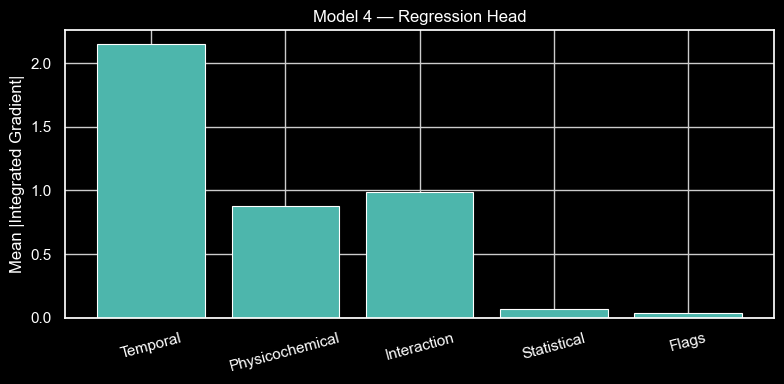

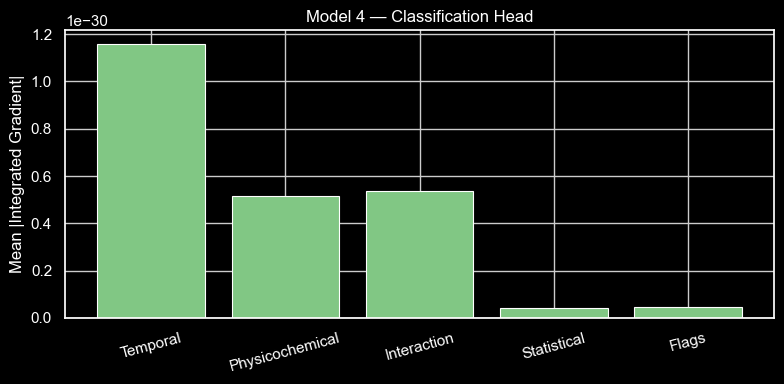

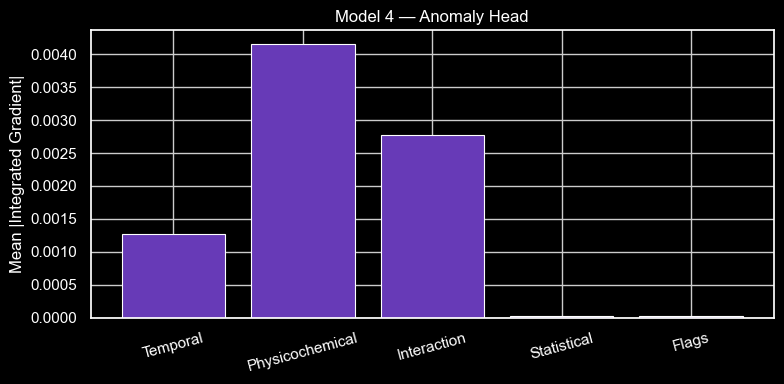

In [251]:
plot_ig(summary_reg,  "Model 4 — Regression Head", COLORS["reg"])
plot_ig(summary_cls,  "Model 4 — Classification Head", COLORS["cls"])
plot_ig(summary_anom, "Model 4 — Anomaly Head", COLORS["anom"])

### Validation Enhancements

#### Cross-Validation

In [184]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)
# One-hot encode categorical columns
X_train_enc = pd.get_dummies(X_train, drop_first=True)

In [186]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
import xgboost as xgb

r2_scores = []
rmse_scores = []

for train_idx, val_idx in tscv.split(X_train_enc):
    X_tr = X_train_enc.iloc[train_idx]
    X_val = X_train_enc.iloc[val_idx]

    y_tr = y_train_reg[train_idx]
    y_val = y_train_reg[val_idx]

    model = xgb.XGBRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_tr, y_tr)
    preds = model.predict(X_val)

    r2_scores.append(r2_score(y_val, preds))
    rmse_scores.append(np.sqrt(mean_squared_error(y_val, preds)))

print("TimeSeries CV R² :", np.mean(r2_scores))
print("TimeSeries CV RMSE:", np.mean(rmse_scores))

TimeSeries CV R² : 0.9996073246002197
TimeSeries CV RMSE: 0.23188867953394388


#### Residual Analysis for Model 1

In [187]:
# Combine train and test temporarily
X_all = pd.concat([X_train, X_test], axis=0)

# One-hot encode together
X_all_enc = pd.get_dummies(X_all, drop_first=True)

In [188]:
X_train_enc = X_all_enc.iloc[:len(X_train)]
X_test_enc  = X_all_enc.iloc[len(X_train):]

In [189]:
X_train_enc.shape[1] == X_test_enc.shape[1]  # ✅ TRUE

True

In [190]:
# Train
model.fit(X_train_enc, y_train_reg)

# Predict
y_pred_reg = model.predict(X_test_enc)

In [191]:
# Train final model on ENCODED data
final_model = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    random_state=42,
    n_jobs=-1
)

final_model.fit(X_train_enc, y_train_reg)

# Predict test set
y_pred_reg = final_model.predict(X_test_enc)

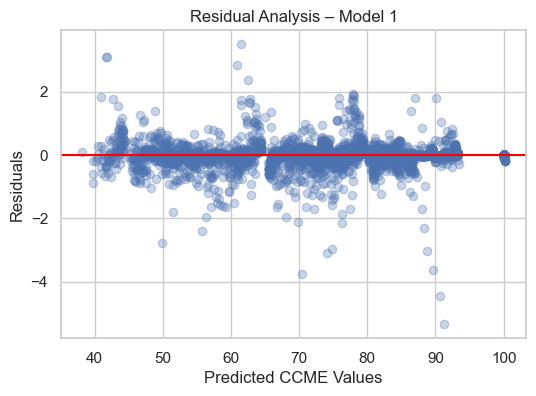

In [192]:
residuals = y_test_reg - y_pred_reg

import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.scatter(y_pred_reg, residuals, alpha=0.3)
plt.axhline(0, color='red')
plt.xlabel("Predicted CCME Values")
plt.ylabel("Residuals")
plt.title("Residual Analysis – Model 1")
plt.show()

#### Residual Analysis for Model 2

In [193]:
objective='multi:softprob'

In [194]:
y_pred_cls = xgb_clf.predict(X_test_processed)

In [195]:
X_test_processed = X_test_processed[X_train_processed.columns]

In [196]:
y_pred_cls = xgb_clf.predict(X_test_processed)

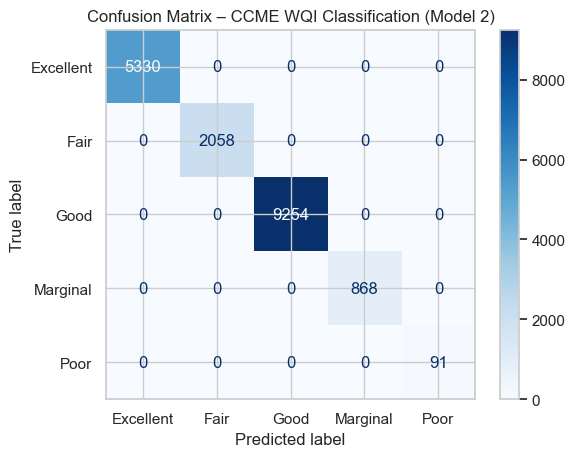

In [197]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

class_names = wqi_encoder.classes_

cm = confusion_matrix(y_test_cls, y_pred_cls)
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(cmap="Blues")
plt.title("Confusion Matrix – CCME WQI Classification (Model 2)")
plt.show()

#### Transform training data

In [198]:
# Transform training data
X_train_processed = preprocessor.transform(X_train)

# Convert to DataFrame WITH INDEX (CRITICAL)
X_train_processed = pd.DataFrame(
    X_train_processed,
    index=X_train.index,
    columns=preprocessor.get_feature_names_out()
)

In [200]:
# Align y with processed X
mask = X_train_processed.notna().all(axis=1)

X_train_processed = X_train_processed.loc[mask]      # keep as is because X is a DataFrame
y_train_reg_final = y_train_reg[mask]                # use [] instead of .loc

In [201]:
assert X_train_processed.shape[0] == len(y_train_reg_final)

In [202]:
final_xgb_reg = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    random_state=42,
    n_jobs=-1
)

final_xgb_reg.fit(
    X_train_processed.values,
    y_train_reg_final
)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None
,feature_types,None


### Deployment Process

#### Deployment Setup

In [203]:
# ===============================
# DEPLOYMENT SETUP
# ===============================
import joblib
import json
import tensorflow as tf
import pandas as pd
import numpy as np
import os

#### Save Processed Feature Indices

In [204]:
# ===============================
# SAVE PROCESSED FEATURE INDICES
# ===============================
import joblib
import json
import os

processed_feature_names = preprocessor.get_feature_names_out()

def get_indices(feature_list):
    return [
        i for i, name in enumerate(processed_feature_names)
        if any(name.endswith(f) or name == f for f in feature_list)
    ]

feature_group_indices = {
    "time":  get_indices(time_features),
    "phys":  get_indices(phys_features),
    "inter": get_indices(interaction_features),
    "stats": get_indices(stat_features),
    "flags": get_indices(flag_features)
}

# Sanity check
total = sum(len(v) for v in feature_group_indices.values())
print("Total NN features:", total)

joblib.dump(feature_group_indices, "models/feature_group_indices.joblib")

Total NN features: 100


['models/feature_group_indices.joblib']

In [205]:
feature_group_indices = joblib.load("models/feature_group_indices.joblib")

time_idx  = feature_group_indices["time"]
phys_idx  = feature_group_indices["phys"]
inter_idx = feature_group_indices["inter"]
stats_idx = feature_group_indices["stats"]
flags_idx = feature_group_indices["flags"]

In [206]:
import joblib
import json
import os

os.makedirs("models", exist_ok=True)

# Save regression model
joblib.dump(final_xgb_reg, "models/xgb_regression.joblib")

# Save preprocessing pipeline
joblib.dump(preprocessor, "models/preprocessor.joblib")

joblib.dump({
    "time": time_features,
    "phys": phys_features,
    "inter": interaction_features,
    "stats": stat_features,
    "flags": flag_features
}, "models/feature_groups.joblib")

# Save feature column order
with open("models/feature_columns.json", "w") as f:
    json.dump(feature_cols, f)

# Save label encoder (if used)
if 'wqi_encoder' in globals():
    joblib.dump(wqi_encoder, "models/wqi_label_encoder.joblib")

# Save neural model (Model 4)
if 'multi_task_model' in globals():
    multi_task_model.save("models/multi_task_model.keras")

print("✅ All models and preprocessing artifacts saved successfully.")

✅ All models and preprocessing artifacts saved successfully.


#### Load all saved models

In [207]:
# Load preprocessing
preprocessor = joblib.load("models/preprocessor.joblib")

# Load models
xgb_reg = joblib.load("models/xgb_regression.joblib")
xgb_cls = joblib.load("models/xgb_classification.joblib")
xgb_anom = joblib.load("models/xgb_anomaly.joblib")
iso_forest = joblib.load("models/isolation_forest.joblib")

multi_task_model = tf.keras.models.load_model(
    "models/multi_task_model.keras",
    compile=False
)

# Load metadata
with open("models/feature_columns.json") as f:
    feature_cols = json.load(f)

feature_groups = joblib.load("models/feature_groups.joblib")
feature_group_indices = joblib.load("models/feature_group_indices.joblib")

wqi_encoder = joblib.load("models/wqi_label_encoder.joblib")

print("✅ All deployment artifacts loaded successfully")

✅ All deployment artifacts loaded successfully


#### Prediction Function

In [208]:
# DEPLOYMENT PREDICTION FUNCTION
def deploy_predict(engineered_df: pd.DataFrame):
    """
    engineered_df: DataFrame AFTER feature engineering
    returns: dict with predictions from all models
    """

    # Remove target columns if present
    deploy_features = [
        c for c in feature_cols
        if c not in ["CCME_Values", "CCME_WQI", "InfrastructureAnomaly"]
    ]

    X = engineered_df[deploy_features]
    X_proc = preprocessor.transform(X)
    results = {}

    # Model 1: Regression
    results["CCME_Value_XGB"] = float(
        xgb_reg.predict(X_proc)[0]
    )

    # Model 2: Classification
    cls_probs = xgb_cls.predict_proba(X_proc)[0]
    cls_label = wqi_encoder.inverse_transform(
        [np.argmax(cls_probs)]
    )[0]
    results["CCME_WQI_Class"] = cls_label
    results["CCME_WQI_Probabilities"] = cls_probs.tolist()

    # Model 3: Anomaly
    results["Infra_Anomaly_XGB"] = float(
        xgb_anom.predict_proba(X_proc)[0, 1]
    )

    # Fix IsolationForest feature-name warning
    X_proc_df = pd.DataFrame(
        X_proc,
        columns=feature_cols
    )
    results["Infra_Anomaly_IForest"] = int(
        iso_forest.predict(X_proc_df)[0] == -1
    )

    # Model 4: Neural Multi-task
    idx = feature_group_indices

    preds = multi_task_model(
        [
            X_proc[:, idx["time"]],
            X_proc[:, idx["phys"]],
            X_proc[:, idx["inter"]],
            X_proc[:, idx["stats"]],
            X_proc[:, idx["flags"]],
        ],
        training=False
    )
    results["CCME_Value_NN"] = float(preds[0].numpy()[0][0])
    results["CCME_WQI_NN_Prob"] = preds[1].numpy()[0].tolist()
    results["Infra_Anomaly_NN"] = float(preds[2].numpy()[0][0])

    return results

#### Deployment Sanity Check

In [209]:
# ===============================
# DEPLOYMENT SANITY TEST
# ===============================
sample = test_df.iloc[[0]]   # unseen test row

deployment_result = deploy_predict(sample)

deployment_result

{'CCME_Value_XGB': 89.46773529052734,
 'CCME_WQI_Class': 'Good',
 'CCME_WQI_Probabilities': [2.6117895686184056e-06,
  3.1619053970644018e-06,
  0.9999899864196777,
  1.969433697013301e-06,
  2.2740321128367214e-06],
 'Infra_Anomaly_XGB': 6.320912507362664e-05,
 'Infra_Anomaly_IForest': 0,
 'CCME_Value_NN': 24.736417770385742,
 'CCME_WQI_NN_Prob': [0.5922326445579529,
  0.0006406684988178313,
  0.40712666511535645,
  8.305941083532276e-23,
  4.95386233278335e-30],
 'Infra_Anomaly_NN': 0.4609912037849426}

#### Feature Check

In [235]:
import json

with open("models/feature_columns.json", "r") as f:
    feature_columns = json.load(f)

len(feature_columns), feature_columns[:5]

(100,
 ['Ammonia (mg/l)',
  'Biochemical Oxygen Demand (mg/l)',
  'Dissolved Oxygen (mg/l)',
  'Orthophosphate (mg/l)',
  'pH (ph units)'])

#### Getting sample for the FastAPI Predictions

In [236]:
import json

# sample is the dict you already built from test_df:
payload = {"features": sample}

# produce a JSON string with double quotes
payload_json = json.dumps(payload, ensure_ascii=False)
print(payload_json)   # copy the printed output (it is valid JSON)

{"features": {"Ammonia (mg/l)": 0.41, "Biochemical Oxygen Demand (mg/l)": 4.0, "Dissolved Oxygen (mg/l)": 10.2, "Orthophosphate (mg/l)": 0.144, "pH (ph units)": 6.7, "Temperature (cel)": 11.46, "Nitrogen (mg/l)": 5.0, "Nitrate (mg/l)": 4.5, "Quarter": 3.0, "Ammonia_BOD": 1.64, "Orthophosphate_Temp": 1.65024, "Ammonia_log": 0.3435897043900769, "Orthophosphate_log": 0.13453089295760615, "BOD_scaled": -0.030576553920023116, "pH (ph units)_lag1": 7.97, "pH (ph units)_lag7": 8.32, "pH (ph units)_roll7_mean": 7.6971428571428575, "pH (ph units)_roll7_std": 0.5336888695894026, "Temperature (cel)_lag1": 14.7, "Temperature (cel)_lag7": 19.3, "Temperature (cel)_roll7_mean": 14.01142857142857, "Temperature (cel)_roll7_std": 2.778005450987374, "Dissolved Oxygen (mg/l)_lag1": 9.52, "Dissolved Oxygen (mg/l)_lag7": 9.59, "Dissolved Oxygen (mg/l)_roll7_mean": 9.98142857142857, "Dissolved Oxygen (mg/l)_roll7_std": 0.26785746031692464, "mean_pH_by_Type": 7.705132542499533, "std_Temperature_by_Type": 3.65

In [233]:
import json

# 1. Take one row as DataFrame
sample_df = test_df.iloc[[0]][feature_columns]

# 2. Convert to pure Python dict
sample = sample_df.iloc[0].to_dict()

# 3. Build payload
payload = {"features": sample}

# 4. Convert to JSON
payload_json = json.dumps(payload, ensure_ascii=False)

print(payload_json)

{"features": {"Ammonia (mg/l)": 0.41, "Biochemical Oxygen Demand (mg/l)": 4.0, "Dissolved Oxygen (mg/l)": 10.2, "Orthophosphate (mg/l)": 0.144, "pH (ph units)": 6.7, "Temperature (cel)": 11.46, "Nitrogen (mg/l)": 5.0, "Nitrate (mg/l)": 4.5, "Quarter": 3.0, "Ammonia_BOD": 1.64, "Orthophosphate_Temp": 1.65024, "Ammonia_log": 0.3435897043900769, "Orthophosphate_log": 0.13453089295760615, "BOD_scaled": -0.030576553920023116, "pH (ph units)_lag1": 7.97, "pH (ph units)_lag7": 8.32, "pH (ph units)_roll7_mean": 7.6971428571428575, "pH (ph units)_roll7_std": 0.5336888695894026, "Temperature (cel)_lag1": 14.7, "Temperature (cel)_lag7": 19.3, "Temperature (cel)_roll7_mean": 14.01142857142857, "Temperature (cel)_roll7_std": 2.778005450987374, "Dissolved Oxygen (mg/l)_lag1": 9.52, "Dissolved Oxygen (mg/l)_lag7": 9.59, "Dissolved Oxygen (mg/l)_roll7_mean": 9.98142857142857, "Dissolved Oxygen (mg/l)_roll7_std": 0.26785746031692464, "mean_pH_by_Type": 7.705132542499533, "std_Temperature_by_Type": 3.65

#### Set environment
##### source /Users/mohammadabuhuzaifa/tf_env/bin/activate
#### FastAPI running command
##### uvicorn app:app --reload
#### Streamlit running command
##### streamlit run streamlit_app.py